**Background**:

We are a small startup focusing mainly on providing machine learning solutions in the European banking market. We work on a variety of problems including fraud detection, sentiment classification and customer intention prediction and classification.

We are interested in developing a robust machine learning system that leverages information coming from call center data.

Ultimately, we are looking for ways to improve the success rate for calls made to customers for any product that our clients offer. Towards this goal we are working on designing an ever evolving machine learning product that offers high success outcomes while offering interpretability for our clients to make informed decisions.

**Data Description**:

The data comes from direct marketing efforts of a European banking institution. The marketing campaign involves making a phone call to a customer, often multiple times to ensure a product subscription, in this case a term deposit. Term deposits are usually short-term deposits with maturities ranging from one month to a few years. The customer must understand when buying a term deposit that they can withdraw their funds only after the term ends. All customer information that might reveal personal information is removed due to privacy concerns.

**Attributes**:

age : age of customer (numeric)

job : type of job (categorical)

marital : marital status (categorical)

education (categorical)

default: has credit in default? (binary)

balance: average yearly balance, in euros (numeric)

housing: has a housing loan? (binary)

loan: has personal loan? (binary)

contact: contact communication type (categorical)

day: last contact day of the month (numeric)

month: last contact month of year (categorical)

duration: last contact duration, in seconds (numeric)

campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)

Output (desired target):

y - has the client subscribed to a term deposit? (binary)


**Goal**(s):

Predict if the customer will subscribe (yes/no) to a term deposit (variable y)

**Success Metric**(s):

Hit %81 or above accuracy by evaluating with 5-fold cross validation and reporting the average performance score.

**Current Challenges**:

We are also interested in finding customers who are more likely to buy the investment product. Determine the segment(s) of customers our client should prioritize.

What makes the customers buy? Tell us which feature we should be focusing more on.

In [34]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from statsmodels.stats.outliers_influence import variance_inflation_factor

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics


# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To oversample and undersample data
!pip install imbalanced-learn # Remove the specific version to allow a compatible install
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To get diferent metric scores
from sklearn.metrics import (
     f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)


# To supress warnings
import warnings

warnings.filterwarnings("ignore")

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
file_path = '/content/drive/MyDrive/Colab Notebooks/term-deposit-marketing-2020.csv'
data = pd.read_csv(file_path)

In [53]:
df = data.copy()

## **EDA**

- Observations
- Sanity checks

In [8]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [ ]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
39995,53,technician,married,tertiary,no,395,no,no,cellular,3,jun,107,1,no
39996,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3,yes
39997,54,admin,divorced,secondary,no,200,no,no,cellular,3,jun,170,1,yes
39998,34,management,married,tertiary,no,1047,no,no,cellular,3,jun,342,1,no
39999,38,technician,married,secondary,no,1442,yes,no,cellular,3,jun,113,1,no


In [10]:
df.shape

(40000, 14)

In [11]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


**Observations -**
* There are no null values in the dataset.
* We can convert the object type columns to categories.

`converting "objects" to "category" reduces the data space required to store the dataframe`

In [9]:
col=df.select_dtypes(include='object')
col.columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'y'],
      dtype='object')

In [10]:
for i in col.columns:
  if i != 'y': # Exclude 'y' from this general categorical conversion
    df[i]=df[i].astype('category')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        40000 non-null  int64   
 1   job        40000 non-null  category
 2   marital    40000 non-null  category
 3   education  40000 non-null  category
 4   default    40000 non-null  category
 5   balance    40000 non-null  int64   
 6   housing    40000 non-null  category
 7   loan       40000 non-null  category
 8   contact    40000 non-null  category
 9   day        40000 non-null  int64   
 10  month      40000 non-null  category
 11  duration   40000 non-null  int64   
 12  campaign   40000 non-null  int64   
 13  y          40000 non-null  object  
dtypes: category(8), int64(5), object(1)
memory usage: 2.1+ MB


* we can see that the memory usage has decreased from 4.3MB to 1.9MB

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,40000.000,40.545,9.642,19.000,33.000,39.000,48.000,95.000
balance,40000.000,1274.278,2903.770,-8019.000,54.000,407.000,1319.000,102127.000
day,40000.000,16.017,8.278,1.000,8.000,17.000,21.000,31.000
duration,40000.000,254.824,259.366,0.000,100.000,175.000,313.000,4918.000
campaign,40000.000,2.882,3.239,1.000,1.000,2.000,3.000,63.000


In [ ]:
df.describe(include='category').T

,count,unique,top,freq
job,40000,12,blue-collar,9383
marital,40000,3,married,24386
education,40000,4,secondary,20993
default,40000,2,no,39191
housing,40000,2,yes,24031
loan,40000,2,no,33070
contact,40000,3,cellular,24914
month,40000,11,may,13532
y,40000,2,no,37104


In [ ]:
for i in col.columns:
    print('Unique values in',i, 'are :')
    print(df[i].value_counts())
    print('*'*50)

Unique values in job are :
job
blue-collar      9383
management       8166
technician       6852
admin            4483
services         3910
retired          1437
self-employed    1414
entrepreneur     1405
unemployed       1104
housemaid        1087
student           524
unknown           235
Name: count, dtype: int64
**************************************************
Unique values in marital are :
marital
married     24386
single      10889
divorced     4725
Name: count, dtype: int64
**************************************************
Unique values in education are :
education
secondary    20993
tertiary     11206
primary       6270
unknown       1531
Name: count, dtype: int64
**************************************************
Unique values in default are :
default
no     39191
yes      809
Name: count, dtype: int64
**************************************************
Unique values in housing are :
housing
yes    24031
no     15969
Name: count, dtype: int64
*****************************

Descriptive Statistics for age:
count   40000.000
mean       40.545
std         9.642
min        19.000
25%        33.000
50%        39.000
75%        48.000
max        95.000
Name: age, dtype: float64




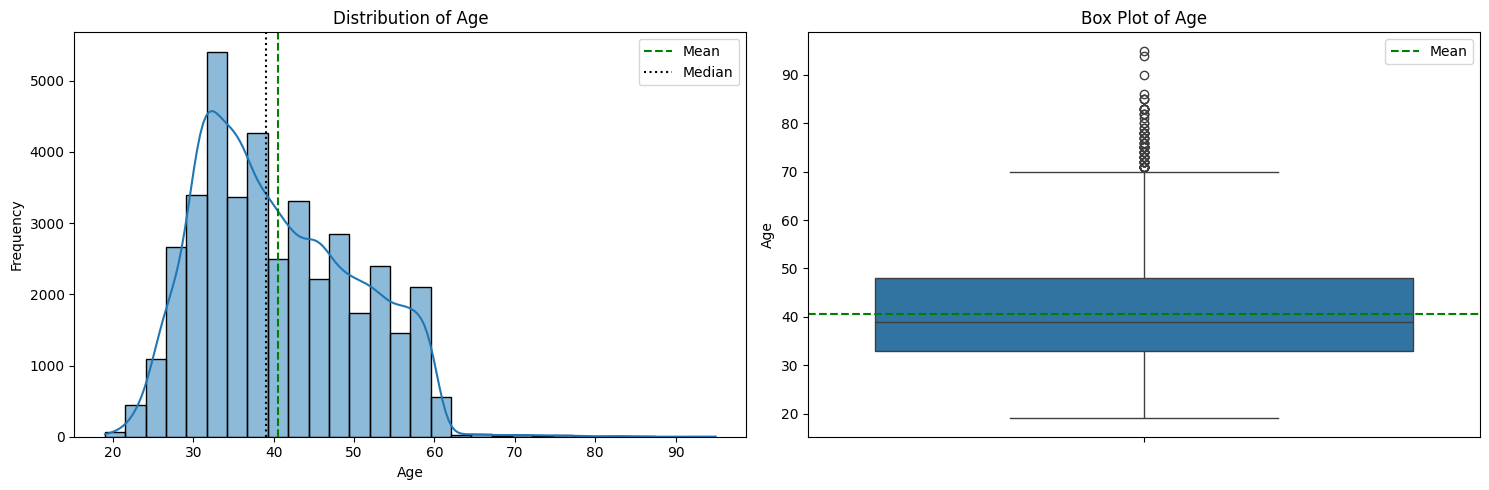

Descriptive Statistics for balance:
count    40000.000
mean      1274.278
std       2903.770
min      -8019.000
25%         54.000
50%        407.000
75%       1319.000
max     102127.000
Name: balance, dtype: float64




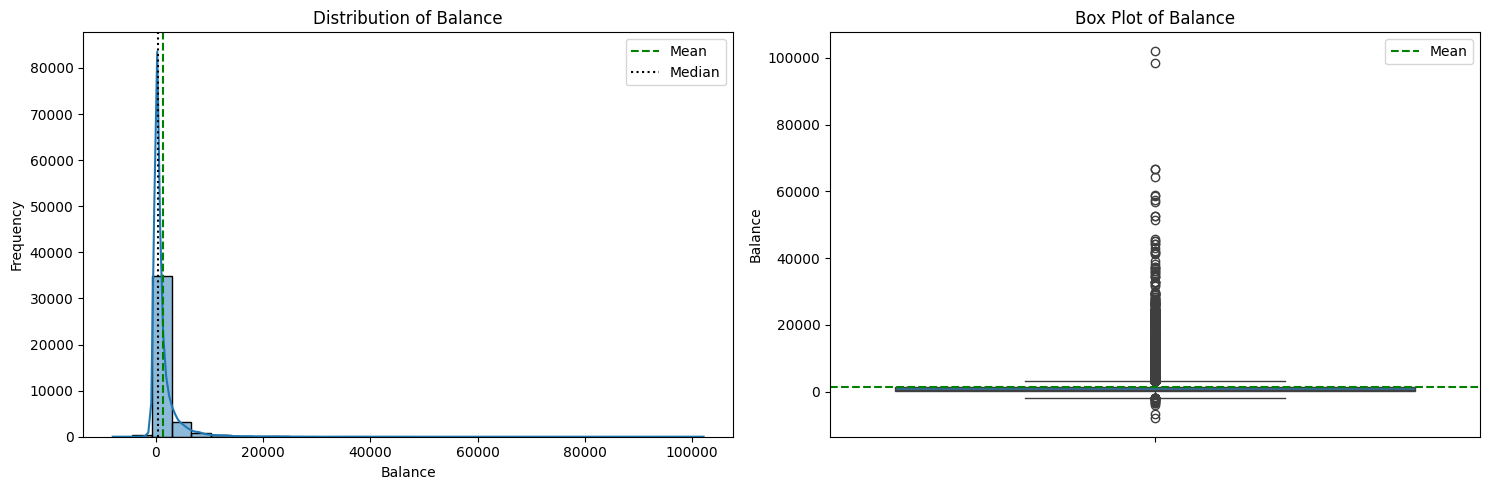

Descriptive Statistics for day:
count   40000.000
mean       16.017
std         8.278
min         1.000
25%         8.000
50%        17.000
75%        21.000
max        31.000
Name: day, dtype: float64




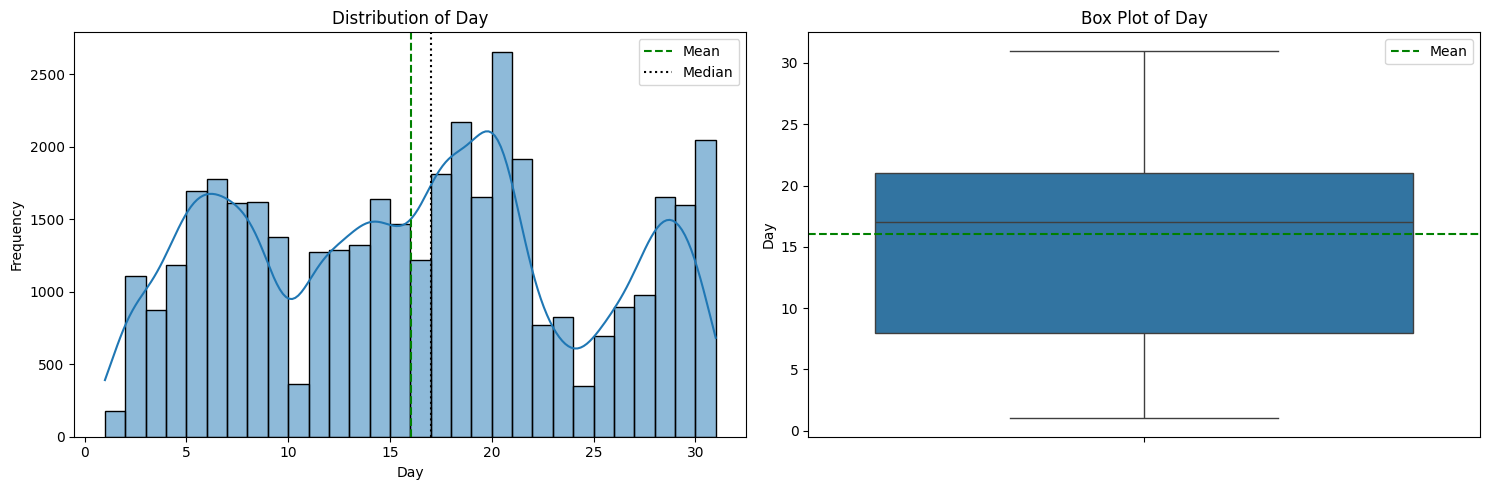

Descriptive Statistics for duration:
count   40000.000
mean      254.824
std       259.366
min         0.000
25%       100.000
50%       175.000
75%       313.000
max      4918.000
Name: duration, dtype: float64




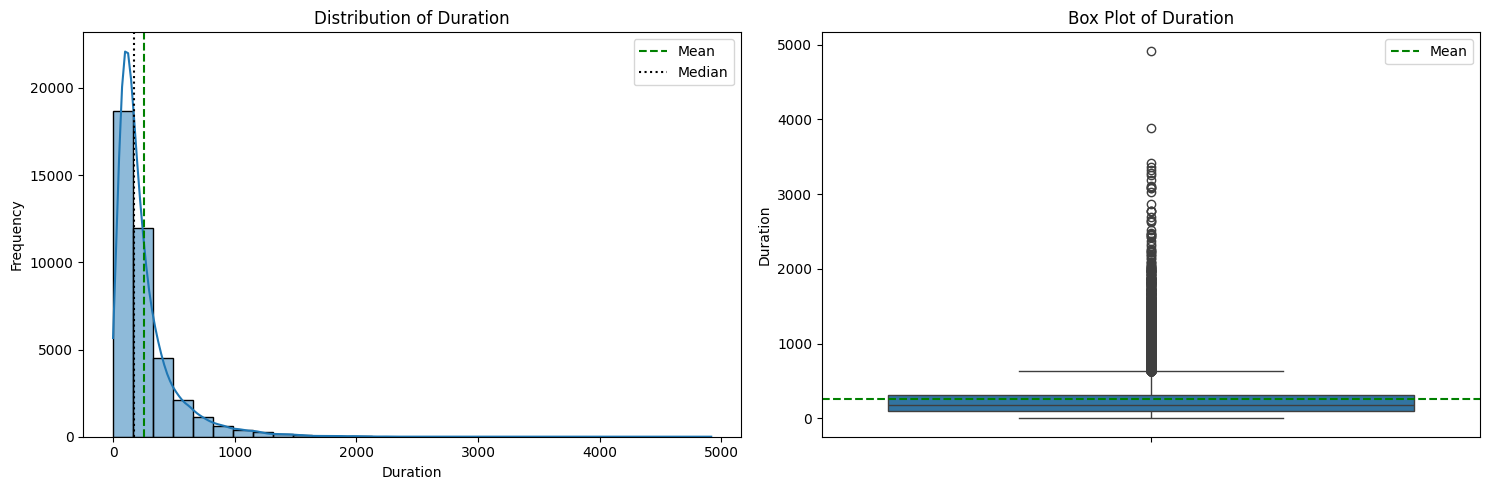

Descriptive Statistics for campaign:
count   40000.000
mean        2.882
std         3.239
min         1.000
25%         1.000
50%         2.000
75%         3.000
max        63.000
Name: campaign, dtype: float64




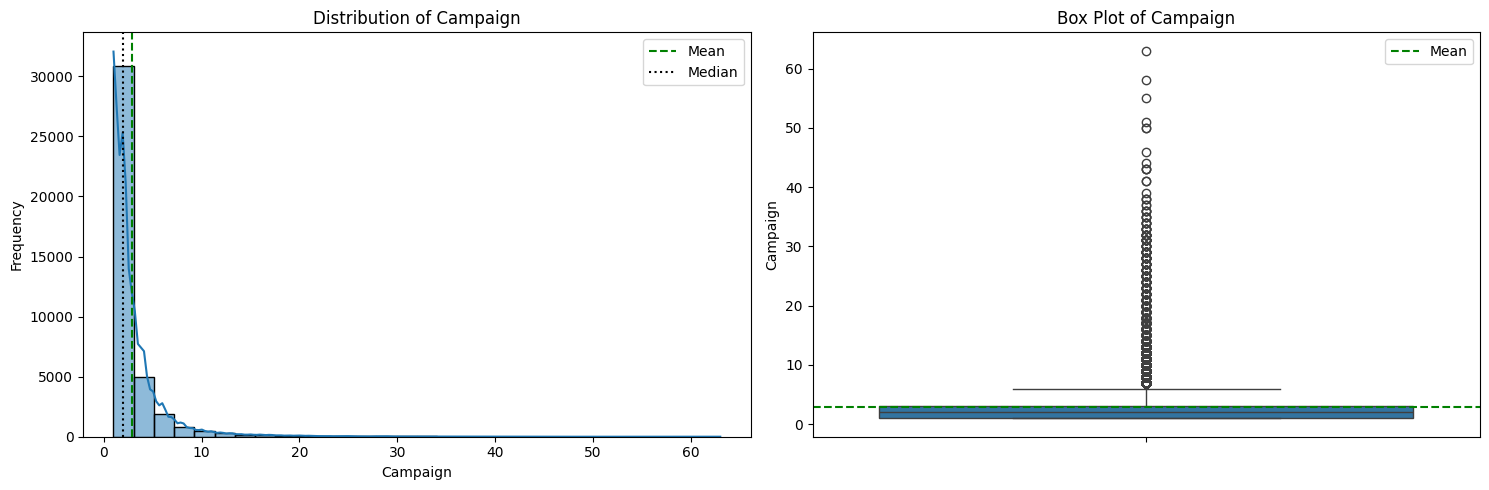

In [ ]:
num_cols = ['age', 'balance', 'day', 'duration', 'campaign']

for col in num_cols:
    print(f"Descriptive Statistics for {col}:")
    print(df[col].describe())
    print("\n" + "="*50 + "\n")

    plt.figure(figsize=(15, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.axvline(df[col].mean(), color='green', linestyle='--', label='Mean')
    plt.axvline(df[col].median(), color='black', linestyle=':', label='Median')
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frequency')
    plt.legend()

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col])
    plt.axhline(df[col].mean(), color='green', linestyle='--', label='Mean')
    plt.title(f'Box Plot of {col.capitalize()}')
    plt.ylabel(col.capitalize())
    plt.legend()

    plt.tight_layout()
    plt.show()

- balance, duration, and campaign exhibit significant right skewness and contain numerous outliers. The balance column also has negative values, which should be understood in the context of the business.
- age shows a slight right skew, but generally follows a more normal distribution compared to others.
- day is relatively uniformly distributed.
- The large number of outliers in balance, duration, and campaign suggests that a small group of customers might behave very differently from the majority. Understanding these segments could be crucial for targeted marketing.






Value Counts for job:
job
blue-collar      9383
management       8166
technician       6852
admin            4483
services         3910
retired          1437
self-employed    1414
entrepreneur     1405
unemployed       1104
housemaid        1087
student           524
unknown           235
Name: count, dtype: int64

Percentages for job:
job
blue-collar     23.457
management      20.415
technician      17.130
admin           11.207
services         9.775
retired          3.592
self-employed    3.535
entrepreneur     3.513
unemployed       2.760
housemaid        2.718
student          1.310
unknown          0.588
Name: proportion, dtype: float64




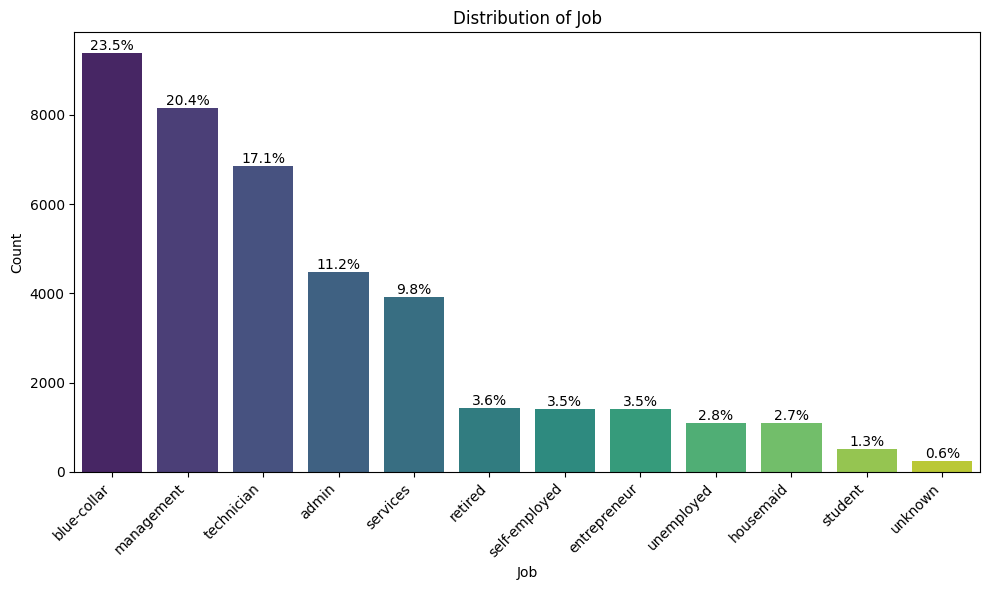

Value Counts for marital:
marital
married     24386
single      10889
divorced     4725
Name: count, dtype: int64

Percentages for marital:
marital
married    60.965
single     27.223
divorced   11.812
Name: proportion, dtype: float64




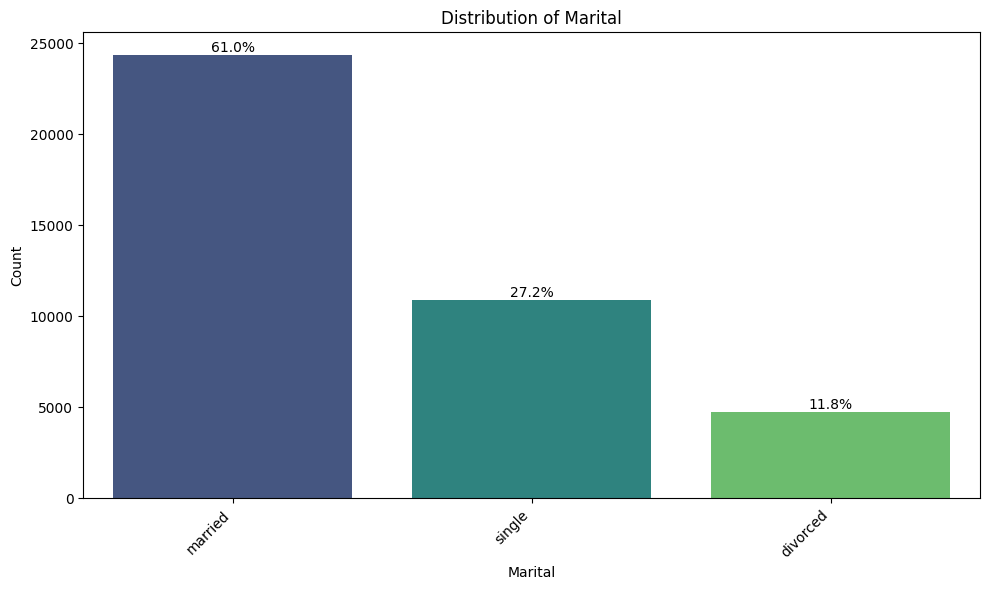

Value Counts for education:
education
secondary    20993
tertiary     11206
primary       6270
unknown       1531
Name: count, dtype: int64

Percentages for education:
education
secondary   52.483
tertiary    28.015
primary     15.675
unknown      3.828
Name: proportion, dtype: float64




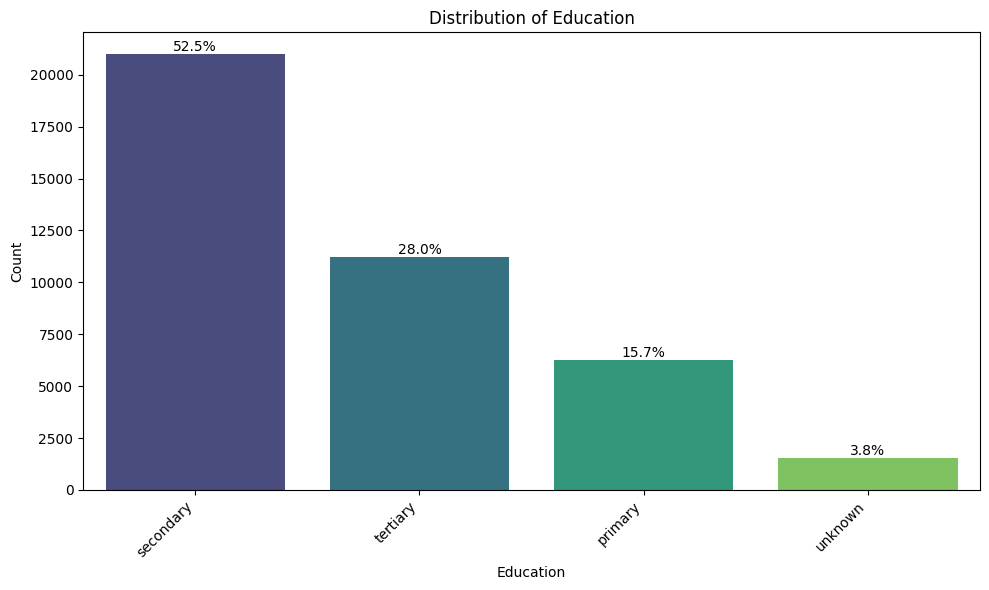

Value Counts for default:
default
no     39191
yes      809
Name: count, dtype: int64

Percentages for default:
default
no    97.977
yes    2.022
Name: proportion, dtype: float64




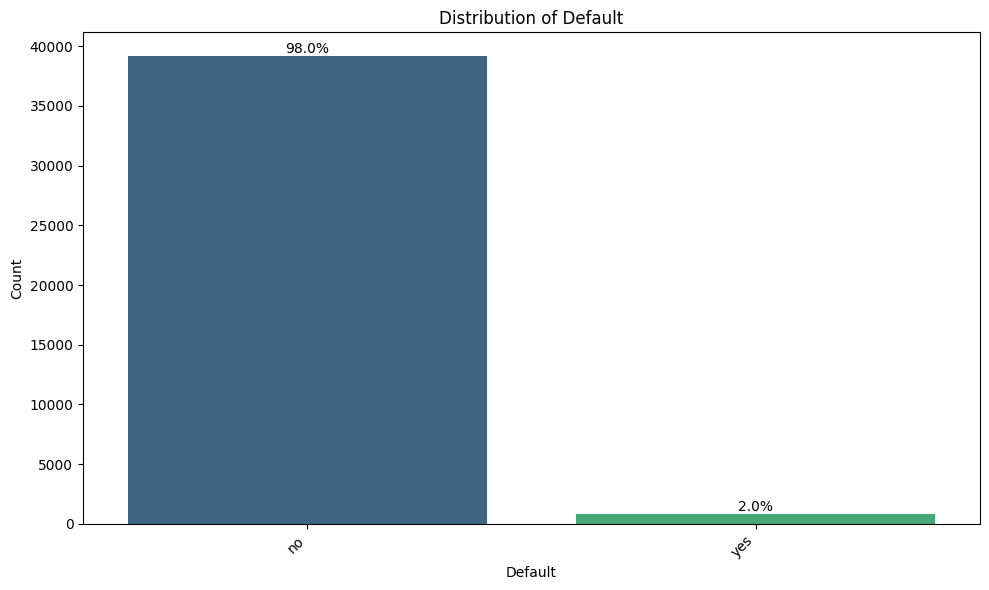

Value Counts for housing:
housing
yes    24031
no     15969
Name: count, dtype: int64

Percentages for housing:
housing
yes   60.077
no    39.922
Name: proportion, dtype: float64




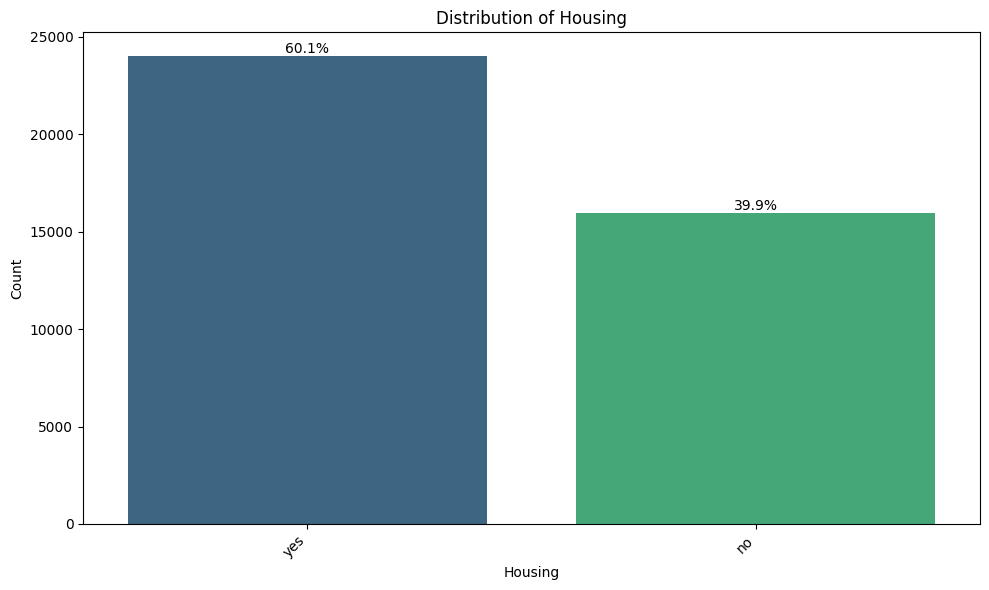

Value Counts for loan:
loan
no     33070
yes     6930
Name: count, dtype: int64

Percentages for loan:
loan
no    82.675
yes   17.325
Name: proportion, dtype: float64




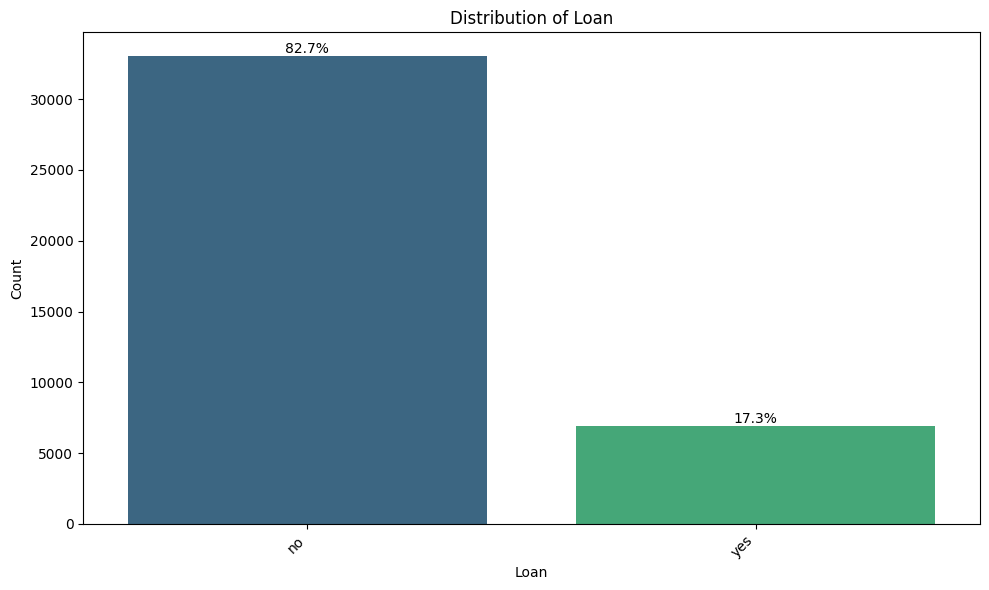

Value Counts for contact:
contact
cellular     24914
unknown      12765
telephone     2321
Name: count, dtype: int64

Percentages for contact:
contact
cellular    62.285
unknown     31.912
telephone    5.803
Name: proportion, dtype: float64




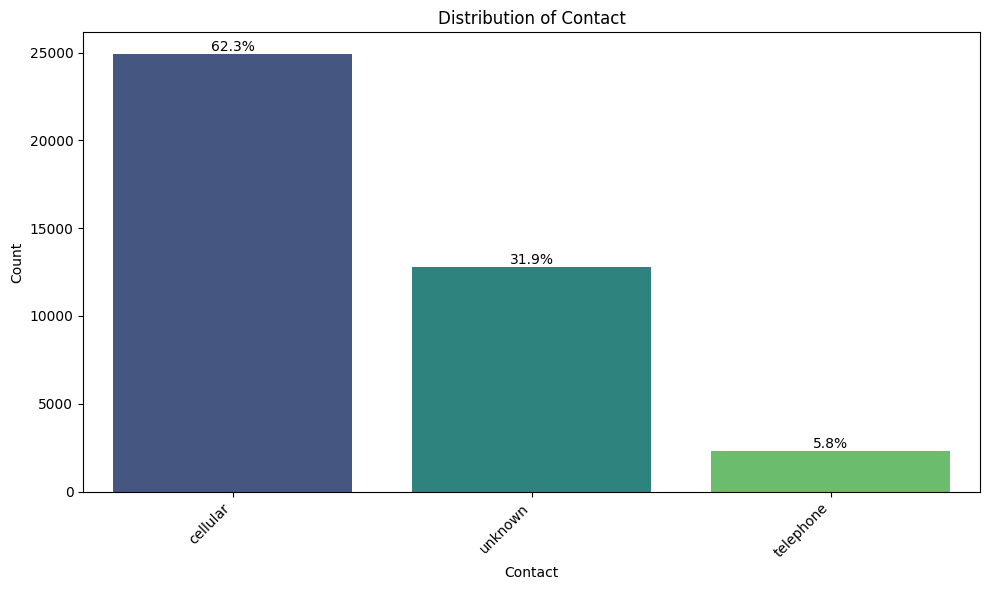

Value Counts for month:
month
may    13532
jul     6380
aug     5215
jun     4734
nov     3598
apr     2718
feb     2296
jan     1176
mar      258
oct       80
dec       13
Name: count, dtype: int64

Percentages for month:
month
may   33.830
jul   15.950
aug   13.037
jun   11.835
nov    8.995
apr    6.795
feb    5.740
jan    2.940
mar    0.645
oct    0.200
dec    0.033
Name: proportion, dtype: float64




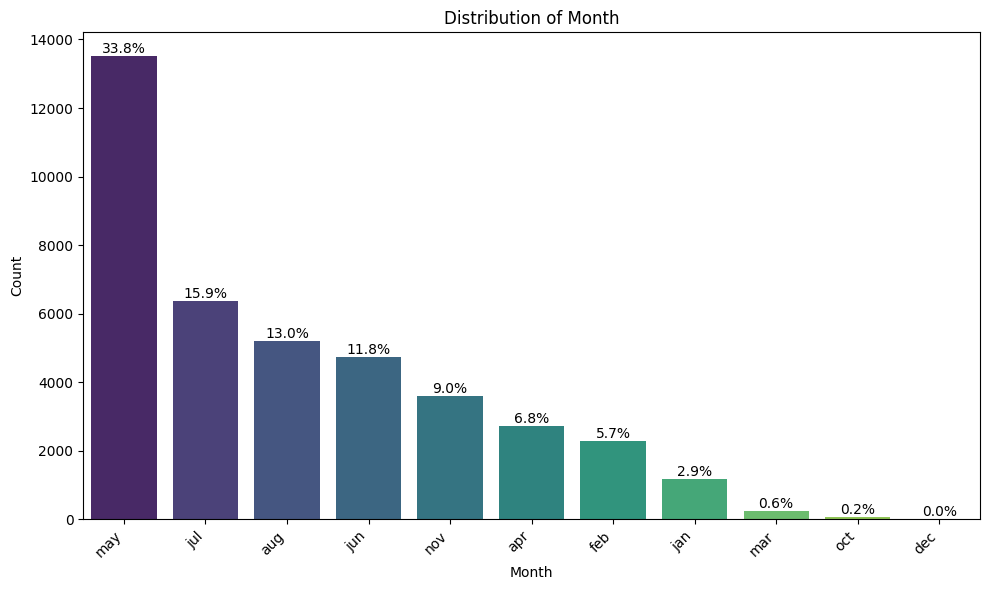

Value Counts for y:
y
no     37104
yes     2896
Name: count, dtype: int64

Percentages for y:
y
no    92.760
yes    7.240
Name: proportion, dtype: float64




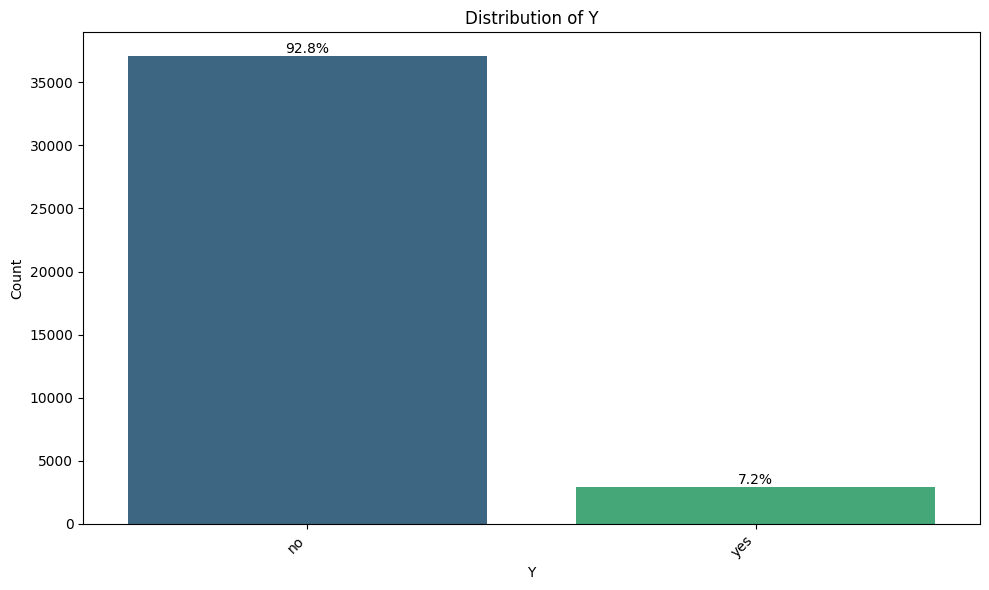

In [7]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'y']

for col in cat_cols:
    print(f"Value Counts for {col}:")
    print(df[col].value_counts())
    print(f"\nPercentages for {col}:")
    print(df[col].value_counts(normalize=True) * 100)
    print("\n" + "="*50 + "\n")

    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df, x=col, palette='viridis', order=df[col].value_counts().index)
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

    # Add percentage labels on top of the bars
    total = len(df[col])
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, color='black')

    plt.tight_layout()
    plt.show()


- The target variable 'y' (term deposit subscription), with 92.76% of customers not subscribing and only 7.24% subscribing.

- Dominant Categorical Groups
    *   Marital Status: 'married' individuals form the largest group (60.97%).
    *   Education: 'secondary' education is most common (52.48%).
    *   Job: 'blue-collar', 'management', and 'technician' are the top three

- Several features ('job', 'education', 'contact') contain an 'unknown' category, indicating missing data that should be addressed.
- Contact activities are concentrated in specific months (May, July, August), suggesting seasonality.
- The default feature is highly imbalanced, with 97.98% of customers having no credit in default. Similarly, 82.67% of customers do not have a personal loan.

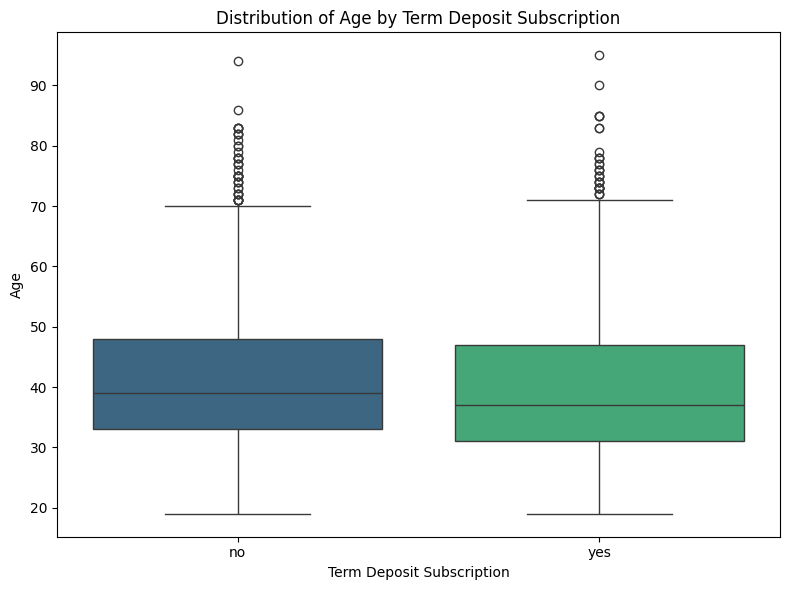

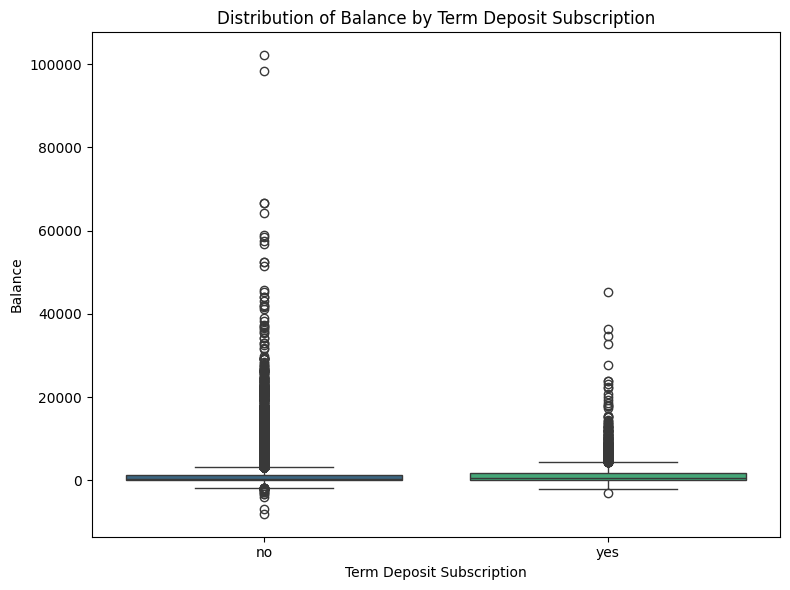

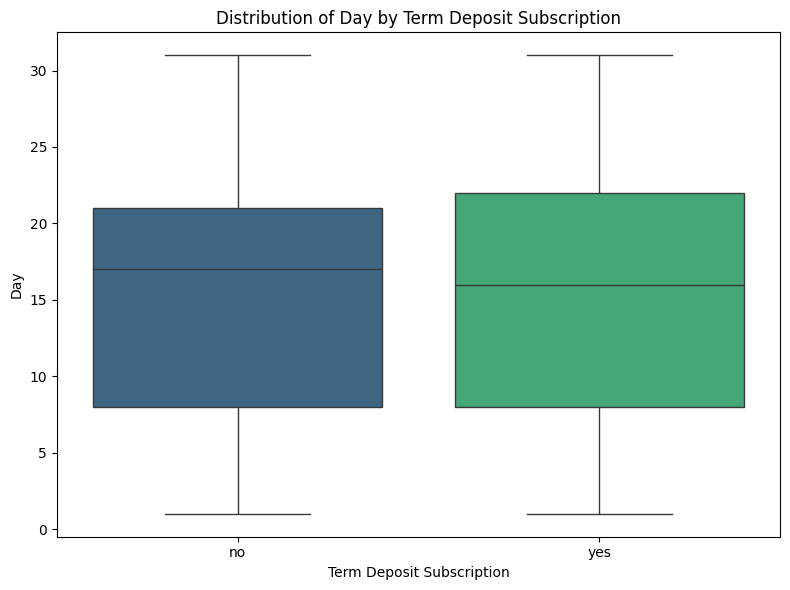

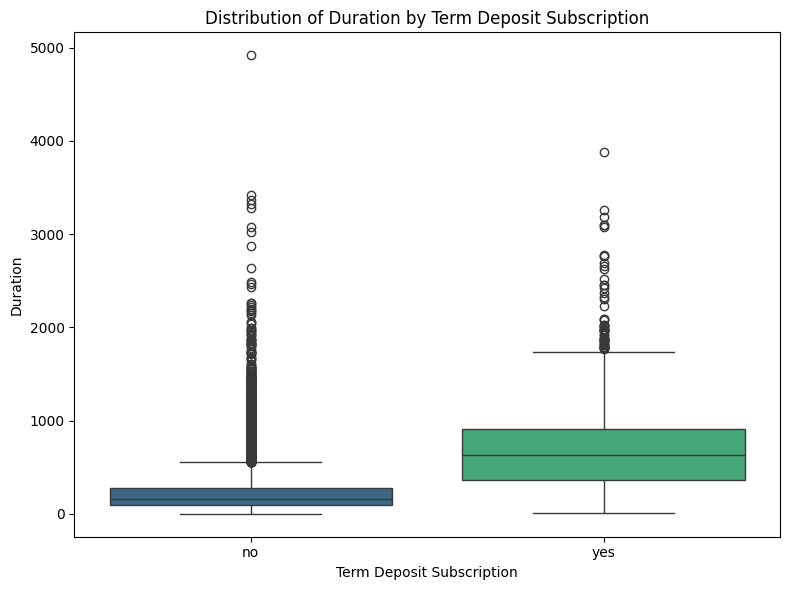

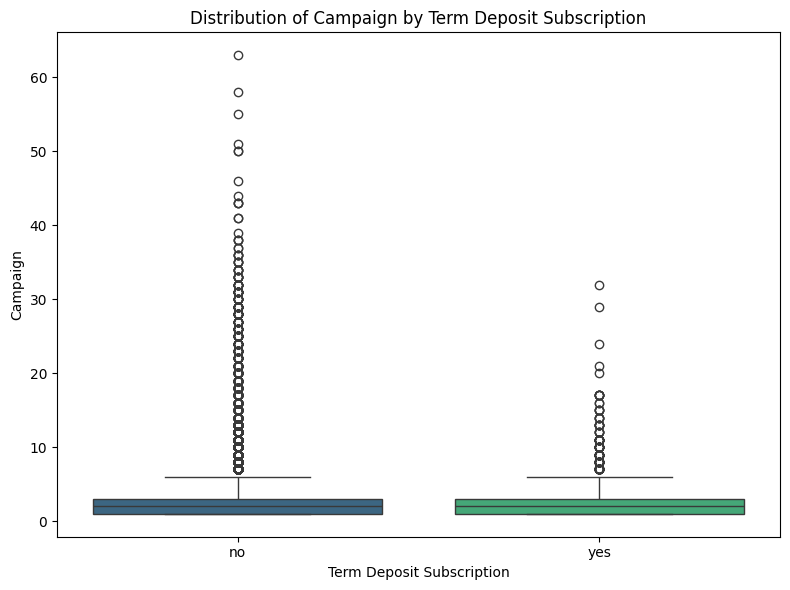

In [ ]:
numerical_features = ['age', 'balance', 'day', 'duration', 'campaign']

for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='y', y=feature, data=df, palette='viridis')
    plt.title(f'Distribution of {feature.capitalize()} by Term Deposit Subscription')
    plt.xlabel('Term Deposit Subscription')
    plt.ylabel(feature.capitalize())
    plt.tight_layout()
    plt.show()

-   Customers with higher average yearly balances are more prone to subscribing. This is a significant finding, as balance appears to be a strong positive indicator for subscription.
-   The day of the month when contact was made does not show a clear difference between subscribers and non-subscribers, suggesting it is not a strong predictor.
-   The duration of the last contact is a highly influential factor. Longer call durations are strongly associated with term deposit subscriptions.
-   Customers who did not subscribe tend to have been contacted more times during the campaign. This suggests that repeatedly contacting customers might not be an effective strategy for conversion, and successful subscriptions often occur with fewer contacts.


## Bivariate Analysis (Categorical vs. Target)




Analysis for Job:

Cross-tabulation (Counts) for Job vs. Y:
y                no  yes
job                     
admin          4132  351
blue-collar    8848  535
entrepreneur   1317   88
housemaid      1034   53
management     7490  676
retired        1286  151
self-employed  1302  112
services       3672  238
student         442   82
technician     6355  497
unemployed     1008   96
unknown         218   17

Cross-tabulation (Percentages) for Job vs. Y (Normalized by row):
y                 no    yes
job                        
admin         92.170  7.830
blue-collar   94.298  5.702
entrepreneur  93.737  6.263
housemaid     95.124  4.876
management    91.722  8.278
retired       89.492 10.508
self-employed 92.079  7.921
services      93.913  6.087
student       84.351 15.649
technician    92.747  7.253
unemployed    91.304  8.696
unknown       92.766  7.234


<Figure size 1000x600 with 0 Axes>

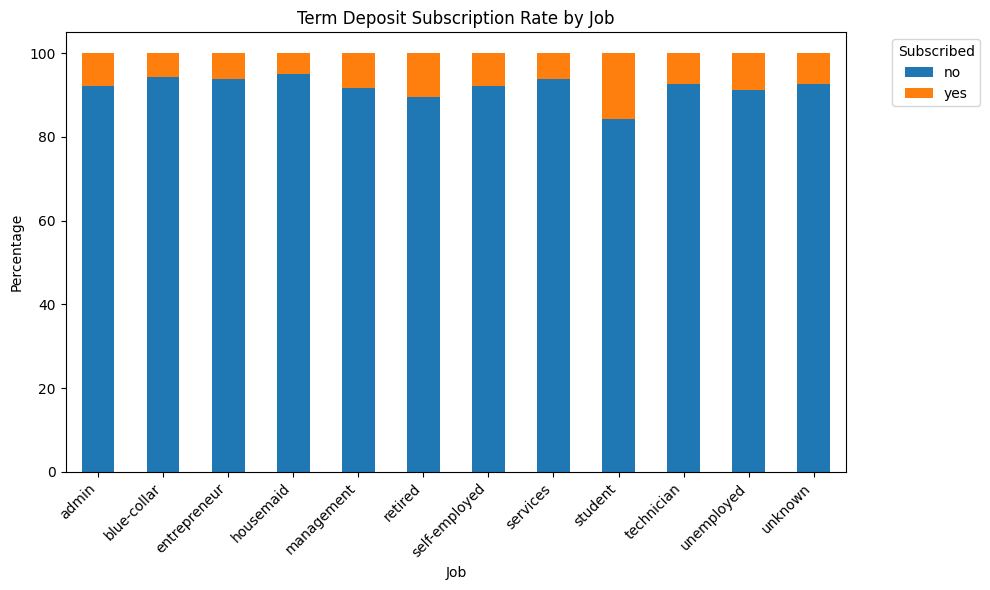


Analysis for Marital:

Cross-tabulation (Counts) for Marital vs. Y:
y            no   yes
marital              
divorced   4334   391
married   22908  1478
single     9862  1027

Cross-tabulation (Percentages) for Marital vs. Y (Normalized by row):
y            no   yes
marital              
divorced 91.725 8.275
married  93.939 6.061
single   90.568 9.432


<Figure size 1000x600 with 0 Axes>

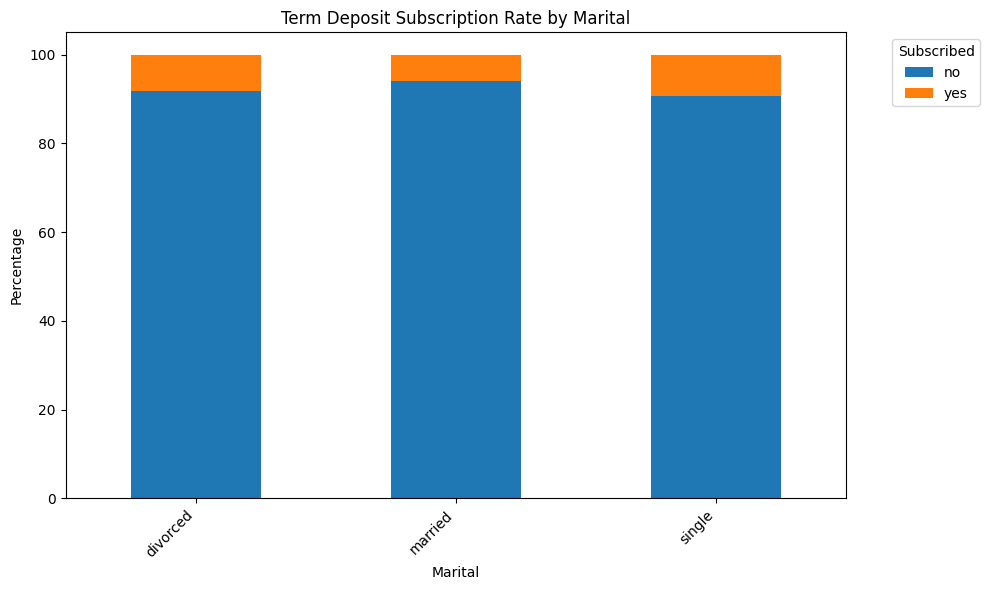


Analysis for Education:

Cross-tabulation (Counts) for Education vs. Y:
y             no   yes
education             
primary     5917   353
secondary  19575  1418
tertiary   10177  1029
unknown     1435    96

Cross-tabulation (Percentages) for Education vs. Y (Normalized by row):
y             no   yes
education             
primary   94.370 5.630
secondary 93.245 6.755
tertiary  90.817 9.183
unknown   93.730 6.270


<Figure size 1000x600 with 0 Axes>

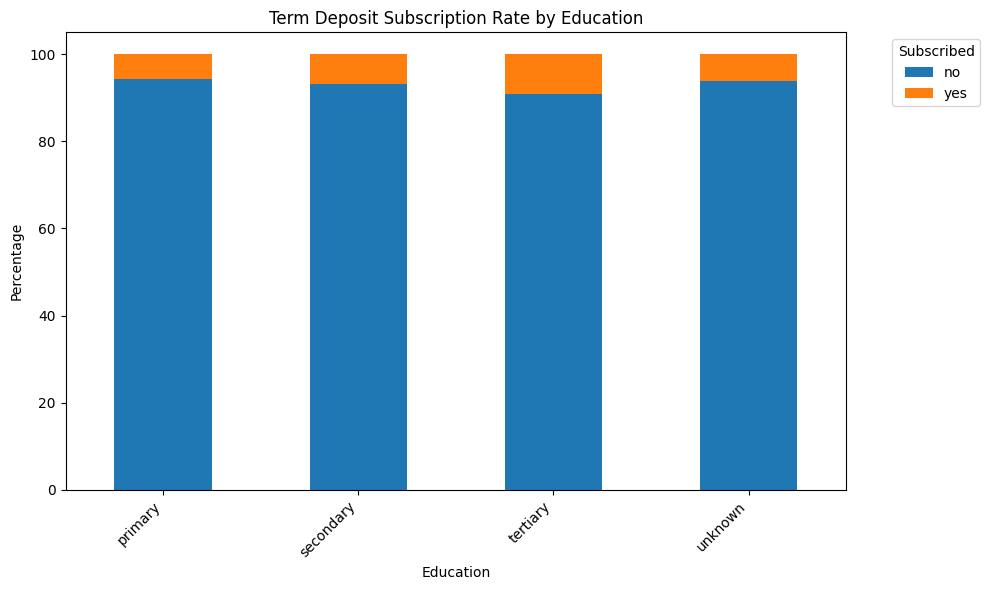


Analysis for Default:

Cross-tabulation (Counts) for Default vs. Y:
y           no   yes
default             
no       36344  2847
yes        760    49

Cross-tabulation (Percentages) for Default vs. Y (Normalized by row):
y           no   yes
default             
no      92.736 7.264
yes     93.943 6.057


<Figure size 1000x600 with 0 Axes>

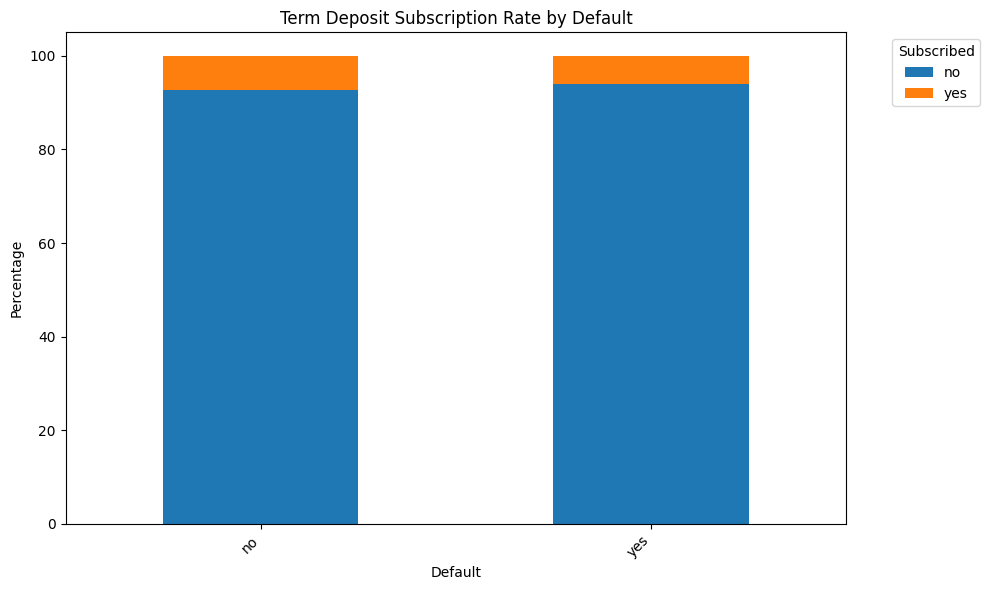


Analysis for Housing:

Cross-tabulation (Counts) for Housing vs. Y:
y           no   yes
housing             
no       14537  1432
yes      22567  1464

Cross-tabulation (Percentages) for Housing vs. Y (Normalized by row):
y           no   yes
housing             
no      91.033 8.967
yes     93.908 6.092


<Figure size 1000x600 with 0 Axes>

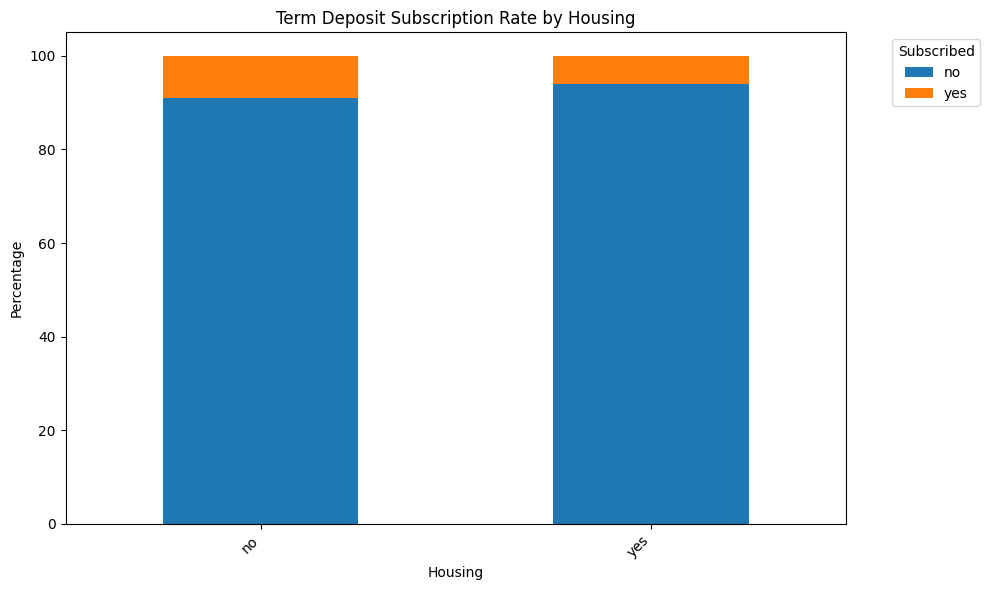


Analysis for Loan:

Cross-tabulation (Counts) for Loan vs. Y:
y        no   yes
loan             
no    30554  2516
yes    6550   380

Cross-tabulation (Percentages) for Loan vs. Y (Normalized by row):
y        no   yes
loan             
no   92.392 7.608
yes  94.517 5.483


<Figure size 1000x600 with 0 Axes>

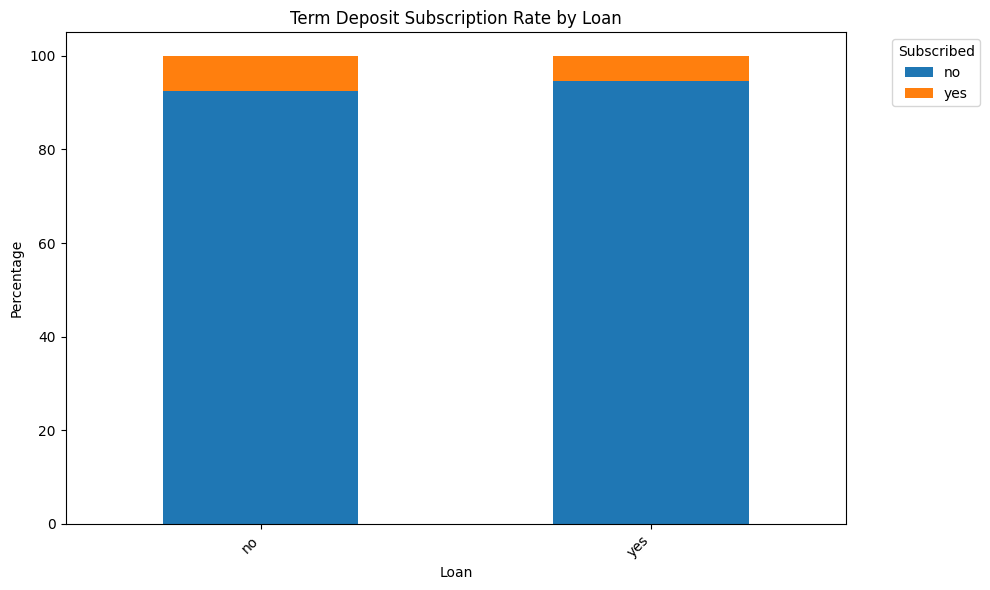


Analysis for Contact:

Cross-tabulation (Counts) for Contact vs. Y:
y             no   yes
contact               
cellular   22681  2233
telephone   2155   166
unknown    12268   497

Cross-tabulation (Percentages) for Contact vs. Y (Normalized by row):
y             no   yes
contact               
cellular  91.037 8.963
telephone 92.848 7.152
unknown   96.107 3.893


<Figure size 1000x600 with 0 Axes>

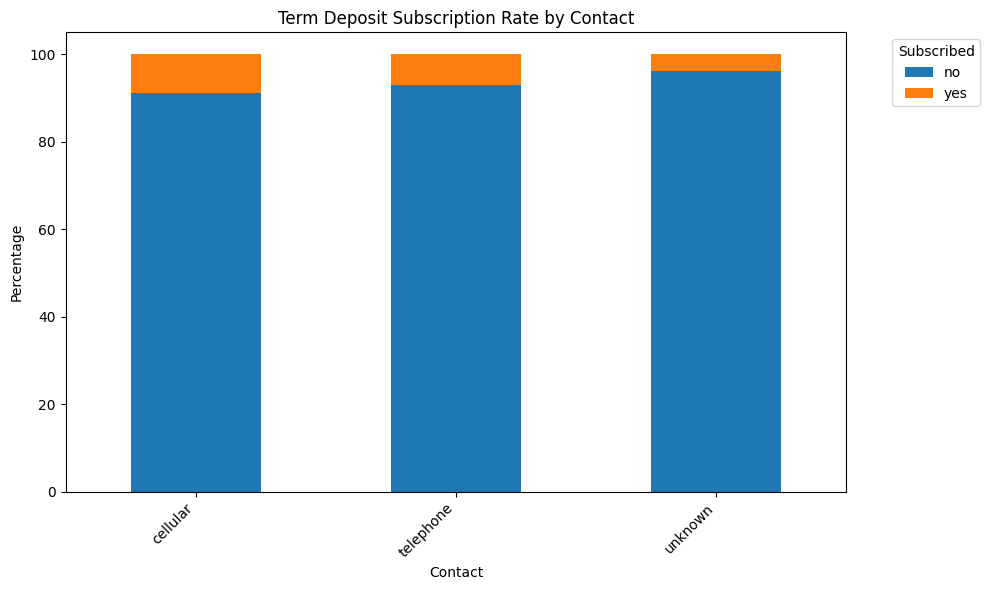


Analysis for Month:

Cross-tabulation (Counts) for Month vs. Y:
y         no  yes
month            
apr     2267  451
aug     4927  288
dec       12    1
feb     2041  255
jan     1138   38
jul     5996  384
jun     4440  294
mar      133  125
may    12741  791
nov     3378  220
oct       31   49

Cross-tabulation (Percentages) for Month vs. Y (Normalized by row):
y         no    yes
month              
apr   83.407 16.593
aug   94.477  5.523
dec   92.308  7.692
feb   88.894 11.106
jan   96.769  3.231
jul   93.981  6.019
jun   93.790  6.210
mar   51.550 48.450
may   94.155  5.845
nov   93.885  6.115
oct   38.750 61.250


<Figure size 1000x600 with 0 Axes>

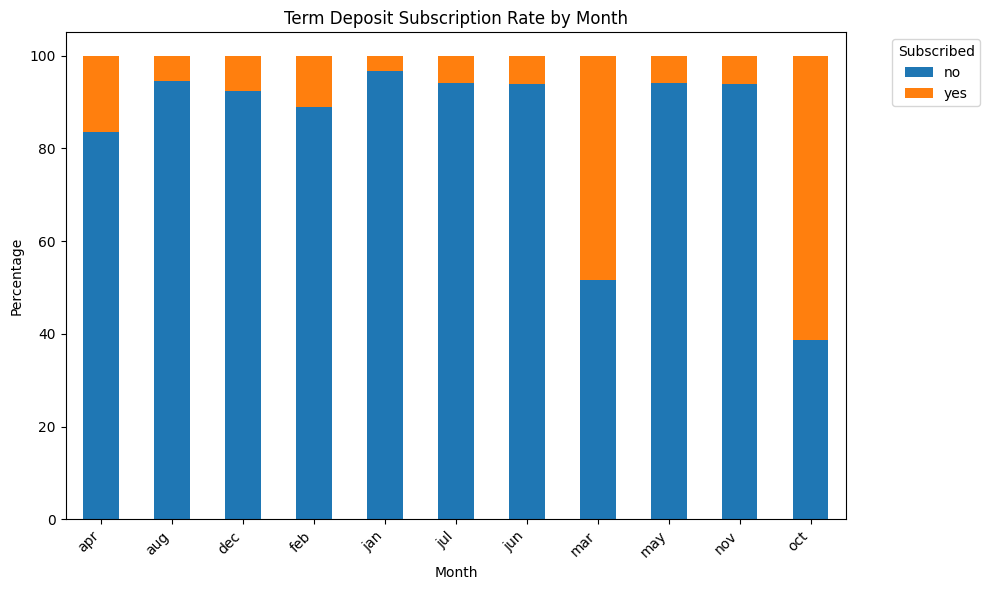

In [ ]:
cat_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month']

for feature in cat_features:
    print(f"\nAnalysis for {feature.capitalize()}:")

    # Cross-tabulation for raw counts
    crosstab_counts = pd.crosstab(df[feature], df['y'])
    print(f"\nCross-tabulation (Counts) for {feature.capitalize()} vs. Y:")
    print(crosstab_counts)

    # Normalize by row to get percentages
    crosstab_percentage = pd.crosstab(df[feature], df['y'], normalize='index') * 100
    print(f"\nCross-tabulation (Percentages) for {feature.capitalize()} vs. Y (Normalized by row):")
    print(crosstab_percentage)

    # Plotting stacked bar chart
    plt.figure(figsize=(10, 6))
    crosstab_percentage.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title(f'Term Deposit Subscription Rate by {feature.capitalize()}')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Percentage')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Subscribed', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


- "job", "marital", "education", "housing", "loan", 'contact', and "month' all show significant variations in subscription rates, indicating their strong predictive power.
- 'Students' and 'retired' individuals, 'single' people, those with 'tertiary' education, customers without 'housing' or 'personal loans', and those contacted via 'cellular' are more likely to subscribe.
- Campaign timing, particularly in 'October' and 'March', is crucial for success.
- The 'unknown' categories in "contact" and 'education", and to a lesser extent "job", are associated with lower subscription rates.
- The 'default' feature shows minimal differentiation and is highly imbalanced, likely making it a weak standalone predictor.


## Bivariate Analysis (Numerical vs. Numerical)





Pair Plot for Numerical Features by 'y':


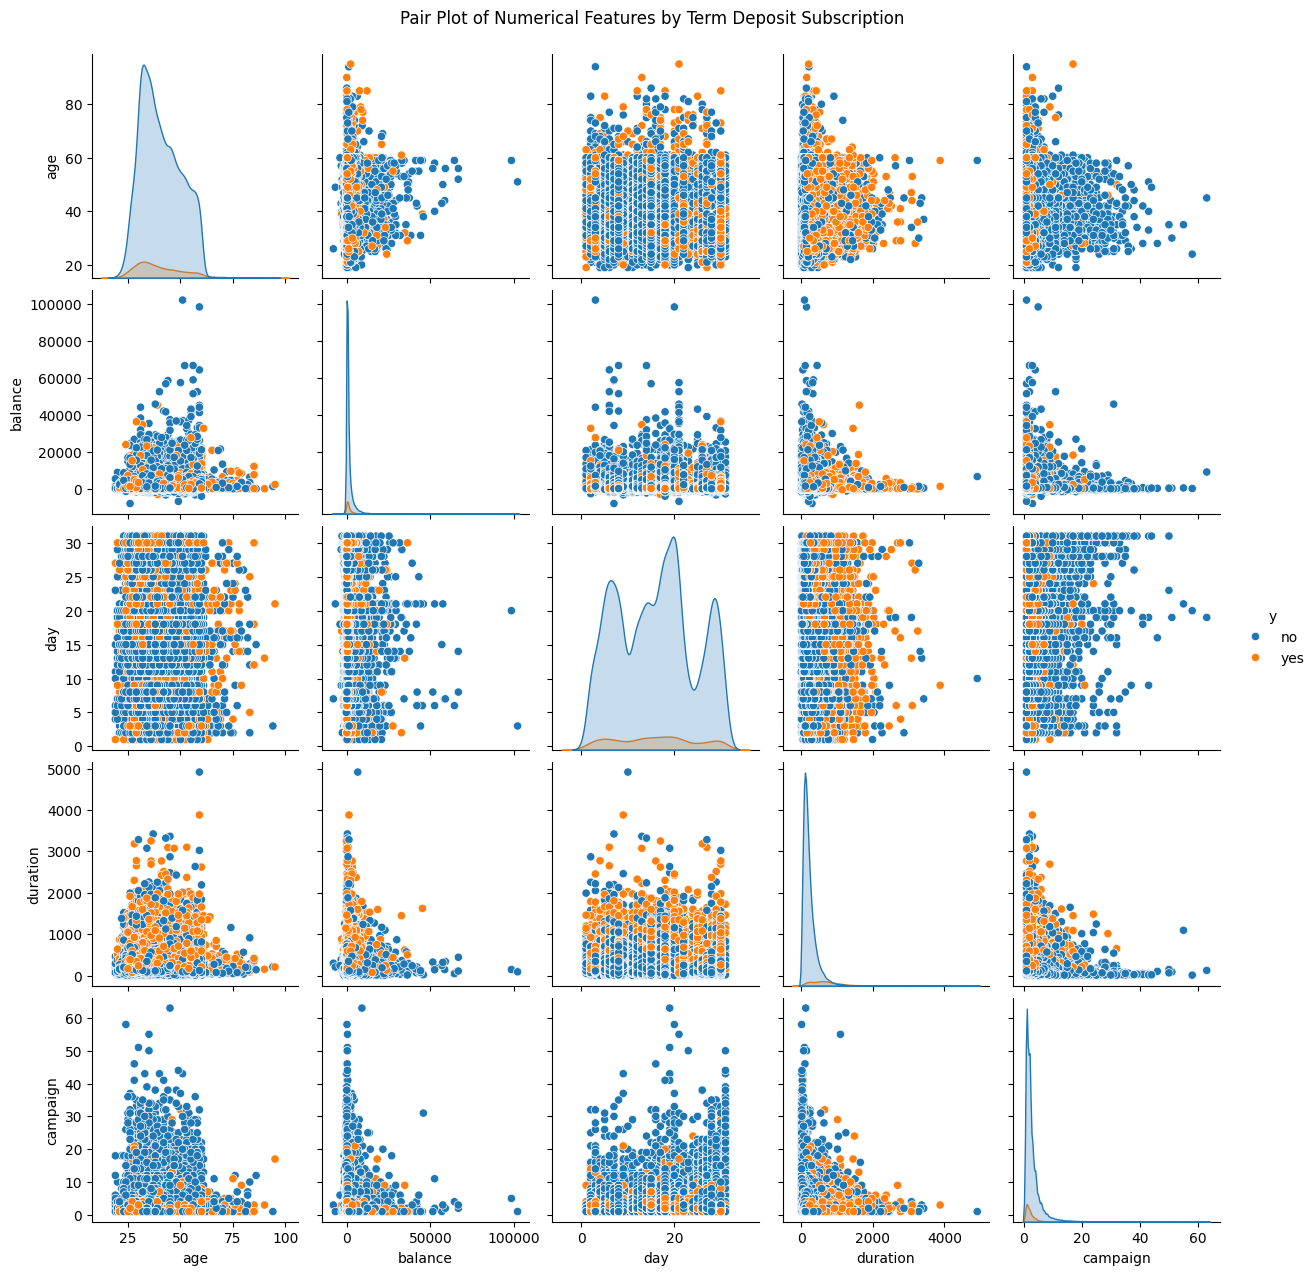

In [8]:
numerical_features = ['age', 'balance', 'day', 'duration', 'campaign']

# Pair plot for numerical features with 'y' as hue
print("\nPair Plot for Numerical Features by 'y':")
sns.pairplot(df[numerical_features + ['y']], hue='y', diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features by Term Deposit Subscription', y=1.02)
plt.show()




- Balance vs. Subscription: The pair plots, particularly the histograms/KDEs split by 'y', visually reinforced that customers with higher 'balance' values are more likely to subscribe. The distribution for 'yes' subscribers tends to be shifted towards higher balance values compared to 'no' subscribers.

- Duration vs. Subscription: The pair plots clearly showed a strong relationship between duration and y. Calls with longer durations are much more frequently associated with a 'yes' subscription. This is evident from the distribution of duration for 'yes' being significantly higher than for 'no'.

- Campaign vs. Subscription: The plots indicated that 'no' subscribers often have a higher campaign count (number of contacts). This suggests that repeated contacts beyond a certain point might be less effective or even counterproductive for conversion.

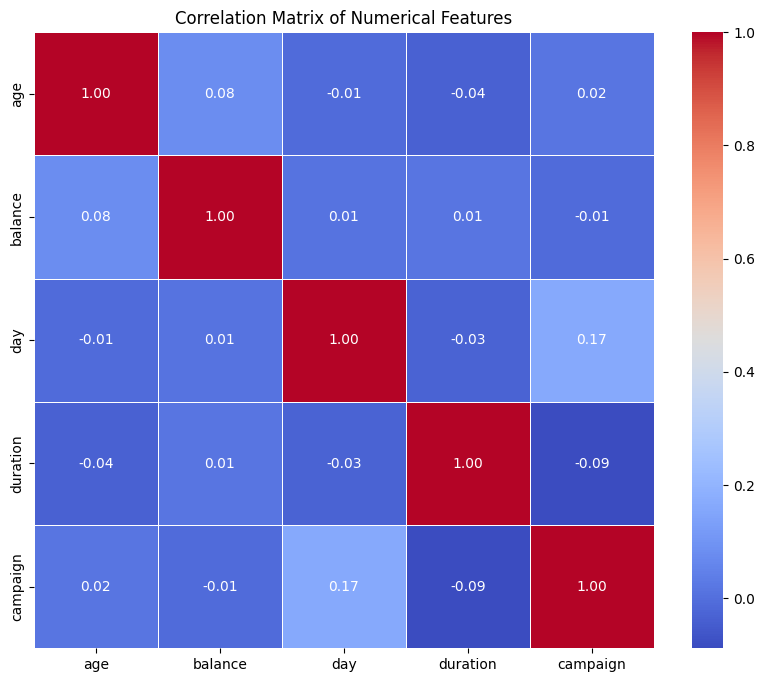

In [ ]:
numerical_features = ['age', 'balance', 'day', 'duration', 'campaign']

# Calculate the correlation matrix
corr_matrix = df[numerical_features].corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

*   Most correlation coefficients were close to zero, indicating little to no linear dependence between these numerical pairs.
*   "duration" showed a weak negative correlation with "campaign" (-0.09), implying that very long calls might reduce the need for subsequent contacts,


# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [22]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


* There is no missing value in the data.

In [23]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


* we don't need feature engineering.

### Outlier detection and treatment (if needed)

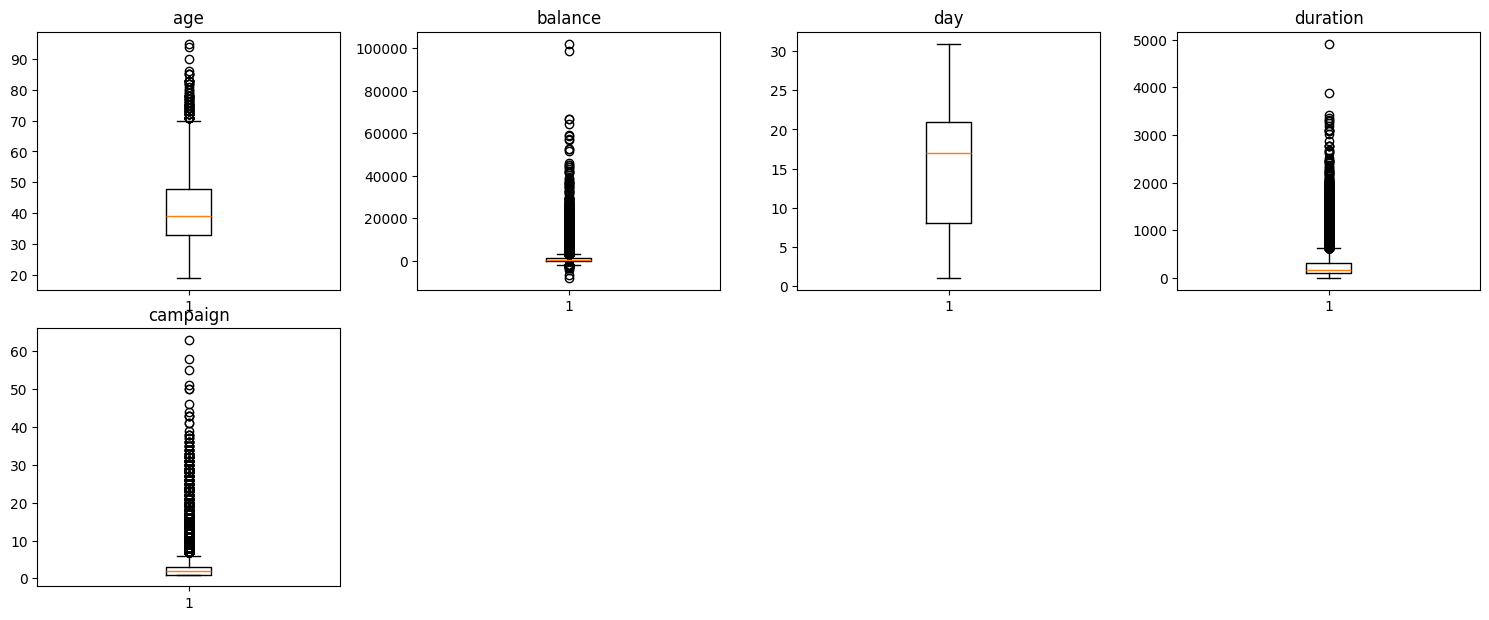

In [24]:
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(15, 12))
for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

* Outliers are true values, we will not treat them.

###  Preparing data for modeling

In [11]:
df['y'] = df['y'].replace({'yes': 1, 'no': 0})


In [12]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,0


In [13]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
39995,53,technician,married,tertiary,no,395,no,no,cellular,3,jun,107,1,0
39996,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3,1
39997,54,admin,divorced,secondary,no,200,no,no,cellular,3,jun,170,1,1
39998,34,management,married,tertiary,no,1047,no,no,cellular,3,jun,342,1,0
39999,38,technician,married,secondary,no,1442,yes,no,cellular,3,jun,113,1,0


In [14]:
# Check the unique values and their counts in the 'y' column before mapping
print(data['y'].value_counts())

y
no     37104
yes     2896
Name: count, dtype: int64


In [15]:
# split independent and dependent variable
X=df.drop('y', axis=1)
y=df['y']

In [16]:
# Splitting the data into train, validation and test set.
X_temp, X_test, y_temp, y_test= train_test_split(X,y, test_size= 0.2, random_state=1, stratify=y)
X_train, X_val, y_train, y_val= train_test_split(X_temp, y_temp, test_size=0.25, random_state=1, stratify= y_temp)
print(X_train.shape, X_val.shape, X_test.shape)

(24000, 13) (8000, 13) (8000, 13)


In [17]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (24000, 13)
Shape of test set :  (8000, 13)
Percentage of classes in training set:
y
0   0.928
1   0.072
Name: proportion, dtype: float64
Percentage of classes in test set:
y
0   0.928
1   0.072
Name: proportion, dtype: float64


In [18]:
# Creating dummy variables
X_train=pd.get_dummies(X_train).astype('float')
X_val=pd.get_dummies(X_val).astype('float')
X_test=pd.get_dummies(X_test).astype("float")
print(X_train.shape, X_val.shape, X_test.shape)


(24000, 44) (8000, 44) (8000, 44)


# **Model Building**

## Model evaluation criterion

**Model can make wrong predictions as:**
1. Predicting client will subscribe to a term deposit but in actual client is not subscribed to a term deposit - Loss of resources
2. Predicting client will not subscribe to a term deposit but in actual client is subscribed to a term deposit.- Loss of opportunity

**Which case is more important?**
* Predicting client will not subscribe to a term deposit but in actual client is going to subscribe (FN) is more important because bank doesn't want to loss client
* We should reduce FN, so we should improve recall, greater the Recall-score lesser the chances of false negatives.

In [21]:
# Let's define a function to output different metrics (including F1 Score) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [22]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [23]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))
models.append(("XGBoost", XGBClassifier(random_state=1)))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9079401611047181
Random forest: 1.0
GBM: 0.42577675489067895
Adaboost: 0.23993095512082854
dtree: 1.0
XGBoost: 0.766398158803222

Validation Performance:

Bagging: 0.3229706390328152
Random forest: 0.18998272884283246
GBM: 0.35233160621761656
Adaboost: 0.25215889464594127
dtree: 0.41278065630397237
XGBoost: 0.4265975820379965


### **Class Weight Parameter**
*In this case, we can pass a dictionary {0:0.20,1:0.80} to the model to specify the weight of each class and the Model will give more weightage to class 1.



In [27]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight={0:0.20,1:0.80}), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight={0:0.20,1:0.80})))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight={0:0.20,1:0.80})))
models.append(("XGBoost", XGBClassifier(random_state=1, scale_pos_weight=4.0)))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9136939010356732
Random forest: 1.0
GBM: 0.42577675489067895
Adaboost: 0.23993095512082854
dtree: 1.0
XGBoost: 0.9706559263521288

Validation Performance:

Bagging: 0.3126079447322971
Random forest: 0.2141623488773748
GBM: 0.35233160621761656
Adaboost: 0.25215889464594127
dtree: 0.40414507772020725
XGBoost: 0.6770293609671848


In [29]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = recall_score(y_train, model.predict(X_train))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9137, Validation Score: 0.3126, Difference: 0.6011
Random forest: Training Score: 1.0000, Validation Score: 0.2142, Difference: 0.7858
GBM: Training Score: 0.4258, Validation Score: 0.3523, Difference: 0.0734
Adaboost: Training Score: 0.2399, Validation Score: 0.2522, Difference: -0.0122
dtree: Training Score: 1.0000, Validation Score: 0.4041, Difference: 0.5959
XGBoost: Training Score: 0.9707, Validation Score: 0.6770, Difference: 0.2936


### GBM, Adaboost, XGboost

### Model Building - Oversampled Data

In [39]:
print("Before Oversampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Certified': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'Denied': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Certified': 1738
Before Oversampling, counts of label 'Denied': 22262 

After Oversampling, counts of label 'Certified': 22262
After Oversampling, counts of label 'Denied': 22262 

After Oversampling, the shape of train_X: (44524, 44)
After Oversampling, the shape of train_y: (44524,) 



In [50]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1)))
print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9955529602012397
Random forest: 1.0
GBM: 0.9573263857694726
Adaboost: 0.9336537597700116
dtree: 1.0
XGBoost: 0.9812685293324949

Validation Performance:

Bagging: 0.4214162348877375
Random forest: 0.30915371329879104
GBM: 0.48013816925734026
Adaboost: 0.44905008635578586
dtree: 0.4697754749568221
XGBoost: 0.4386873920552677


In [48]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9975, Validation Score: 0.4841, Difference: 0.5134
Random forest: Training Score: 1.0000, Validation Score: 0.4144, Difference: 0.5856
GBM: Training Score: 0.9629, Validation Score: 0.5158, Difference: 0.4472
Adaboost: Training Score: 0.9441, Validation Score: 0.4498, Difference: 0.4942
dtree: Training Score: 1.0000, Validation Score: 0.4518, Difference: 0.5482
XGBoost: Training Score: 0.9879, Validation Score: 0.4971, Difference: 0.4908


### Under Sampling

In [43]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [44]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 1738
Before Under Sampling, counts of label 'No': 22262 

After Under Sampling, counts of label 'Yes': 1738
After Under Sampling, counts of label 'No': 1738 

After Under Sampling, the shape of train_X: (3476, 44)
After Under Sampling, the shape of train_y: (3476,) 



In [45]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))
models.append(("XGBoost", XGBClassifier(random_state=1)))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9884925201380897
Random forest: 1.0
GBM: 0.9085155350978136
Adaboost: 0.8043728423475259
dtree: 1.0
XGBoost: 0.9959723820483314

Validation Performance:

Bagging: 0.8808290155440415
Random forest: 0.92573402417962
GBM: 0.9153713298791019
Adaboost: 0.7823834196891192
dtree: 0.8203799654576857
XGBoost: 0.9136442141623489


In [54]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = recall_score(y_train_un, model.predict(X_train_un))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9885, Validation Score: 0.8808, Difference: 0.1077
Random forest: Training Score: 1.0000, Validation Score: 0.9257, Difference: 0.0743
GBM: Training Score: 0.9085, Validation Score: 0.9154, Difference: -0.0069
Adaboost: Training Score: 0.8044, Validation Score: 0.7824, Difference: 0.0220
dtree: Training Score: 1.0000, Validation Score: 0.8204, Difference: 0.1796
XGBoost: Training Score: 0.9960, Validation Score: 0.9136, Difference: 0.0823


## For Under Sampling-  Random Forest, GBM, Adaboost, XG boost

# Random Forest, GBM, Adaboost, XGboost

# Hyper parameter Tuning Random Forest

##

Best hyper‑parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 4, 'max_depth': np.int64(6), 'class_weight': 'balanced'}

Random‑forest performance on training set:
   Accuracy  Recall  Precision    F1
0     0.871   0.891      0.347 0.499

Random‑forest performance on test set:
   Accuracy  Recall  Precision    F1
0     0.863   0.860      0.329 0.476

Confusion matrix – training set

Confusion matrix – test set


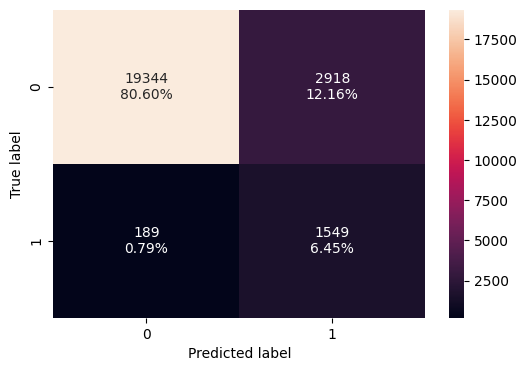

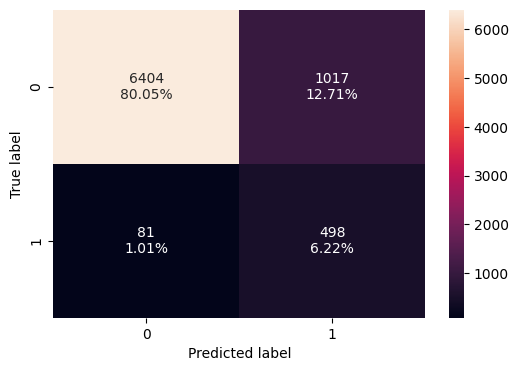

In [62]:
# hyper–parameter tuning for a random‑forest classifier and evaluation on
# both the training and the hold‑out test set

# base estimator
rf = RandomForestClassifier(random_state=42)

# parameter grid / distribution (re‑use the one defined earlier if already present)
param_dist = {
    "class_weight": [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 5}, {0: 1, 1: 10}],
    "n_estimators": [50, 100, 200],
    "max_depth": np.arange(1, 7, 1),
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [6, 5, 4],
}

# use recall as the scoring criterion since we care about catching happy customers
scorer = make_scorer(recall_score)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

best_rf = search.best_estimator_
print("Best hyper‑parameters:", search.best_params_)

# evaluate performance
rf_train_perf = model_performance_classification_sklearn(best_rf, X_train, y_train)
rf_test_perf = model_performance_classification_sklearn(best_rf, X_val, y_val)

print("\nRandom‑forest performance on training set:")
print(rf_train_perf)

print("\nRandom‑forest performance on test set:")
print(rf_test_perf)

# confusion matrices
print("\nConfusion matrix – training set")
confusion_matrix_sklearn(best_rf, X_train, y_train)
print("\nConfusion matrix – test set")
confusion_matrix_sklearn(best_rf, X_val, y_val)

## Random Forest with Oversampling

Best hyper‑parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 4, 'max_depth': np.int64(6), 'class_weight': 'balanced'}

Random‑forest performance on training set:
   Accuracy  Recall  Precision    F1
0     0.871   0.891      0.347 0.499

Random‑forest performance on test set:
   Accuracy  Recall  Precision    F1
0     0.865   0.865      0.334 0.481

Confusion matrix – training set

Confusion matrix – test set


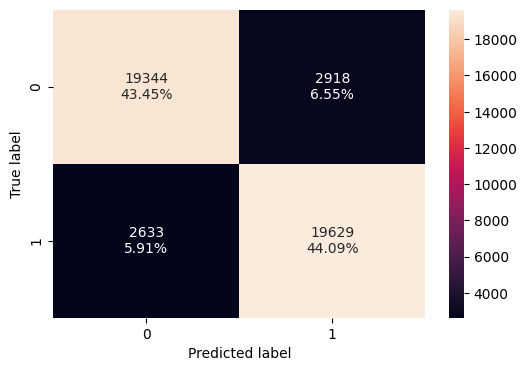

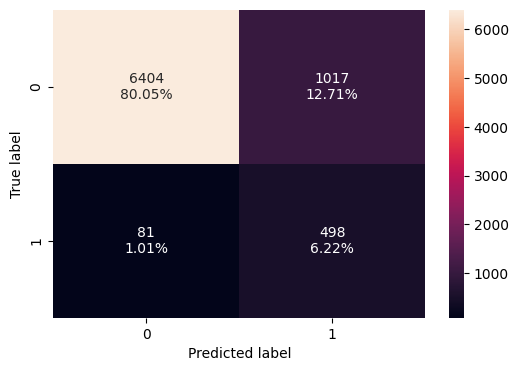

In [58]:
# hyper–parameter tuning for a random‑forest classifier and evaluation on
# both the training and the hold‑out test set

# base estimator
rf = RandomForestClassifier(random_state=42)

# parameter grid / distribution (re‑use the one defined earlier if already present)
param_dist = {
    "class_weight": [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 5}, {0: 1, 1: 10}],
    "n_estimators": [50, 100, 200],
    "max_depth": np.arange(1, 7, 1),
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [6, 5, 4],
}

# use recall as the scoring criterion since we care about catching happy customers
scorer = make_scorer(recall_score)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

best_rf = search.best_estimator_
print("Best hyper‑parameters:", search.best_params_)

# evaluate performance
rf_train_perf = model_performance_classification_sklearn(best_rf, X_train, y_train)
rf_test_perf = model_performance_classification_sklearn(best_rf, X_val, y_val)

print("\nRandom‑forest performance on training set:")
print(rf_train_perf)

print("\nRandom‑forest performance on test set:")
print(rf_test_perf)

# confusion matrices
print("\nConfusion matrix – training set")
confusion_matrix_sklearn(best_rf, X_train_over, y_train_over)
print("\nConfusion matrix – test set")
confusion_matrix_sklearn(best_rf, X_val, y_val)

### Random Forest with undersampling

Best hyper‑parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 4, 'max_depth': np.int64(6), 'class_weight': 'balanced'}

Random‑forest performance on training set:
   Accuracy  Recall  Precision    F1
0     0.881   0.892      0.872 0.882

Random‑forest performance on test set:
   Accuracy  Recall  Precision    F1
0     0.864   0.874      0.333 0.482

Confusion matrix – training set

Confusion matrix – test set


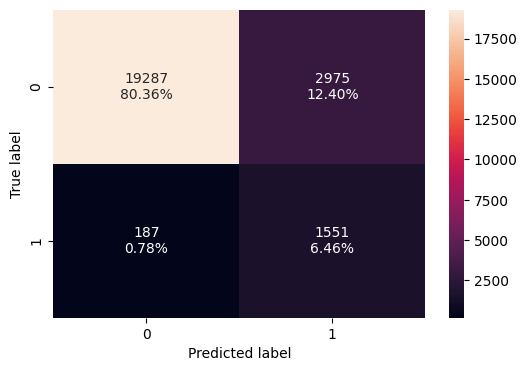

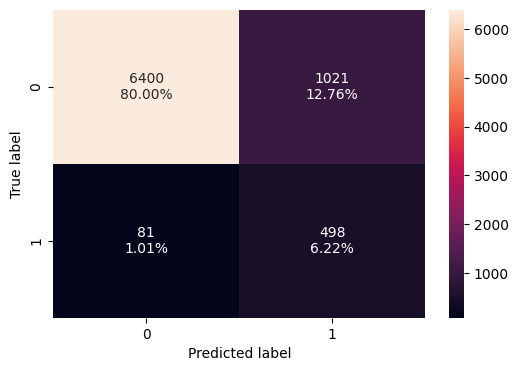

In [61]:
# hyper–parameter tuning for a random‑forest classifier and evaluation on
# both the training and the hold‑out test set

# base estimator
rf = RandomForestClassifier(random_state=42)

# parameter grid / distribution (re‑use the one defined earlier if already present)
param_dist = {
    "class_weight": [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 5}, {0: 1, 1: 10}],
    "n_estimators": [50, 100, 200],
    "max_depth": np.arange(1, 7, 1),
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [5, 4, 3, 2],
}

# use recall as the scoring criterion since we care about catching happy customers
scorer = make_scorer(recall_score)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

best_rf = search.best_estimator_
print("Best hyper‑parameters:", search.best_params_)

# evaluate performance
rf_train_perf = model_performance_classification_sklearn(best_rf, X_train_un, y_train_un)
rf_test_perf = model_performance_classification_sklearn(best_rf, X_val, y_val)

print("\nRandom‑forest performance on training set:")
print(rf_train_perf)

print("\nRandom‑forest performance on test set:")
print(rf_test_perf)

# confusion matrices
print("\nConfusion matrix – training set")
confusion_matrix_sklearn(best_rf, X_train, y_train)
print("\nConfusion matrix – test set")
confusion_matrix_sklearn(best_rf, X_val, y_val)

# GBM

Best hyper‑parameters: {'subsample': 0.9, 'n_estimators': np.int64(100), 'max_features': 0.7, 'max_depth': np.int64(6), 'learning_rate': 0.05}

Random‑forest performance on training set:
   Accuracy  Recall  Precision    F1
0     0.777   0.560      0.990 0.715

Random‑forest performance on test set:
   Accuracy  Recall  Precision    F1
0     0.939   0.409      0.620 0.493

Confusion matrix – training set

Confusion matrix – test set


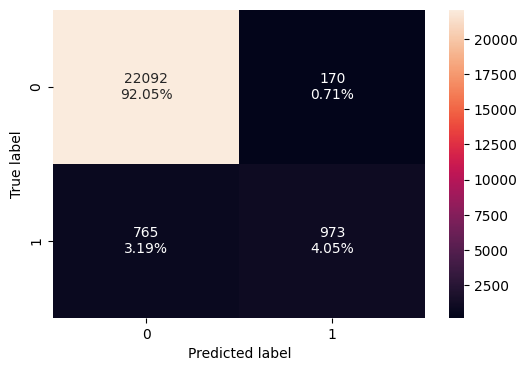

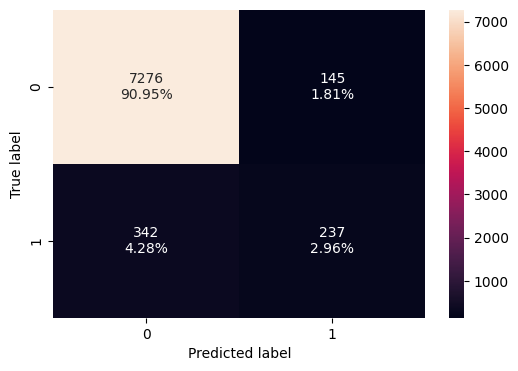

In [68]:
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(random_state=1)

# Grid of parameters to choose from for GradientBoostingClassifier
gbm_param_dist = {
    "n_estimators": np.arange(25,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.5,0.7,0.9],
    "max_features":[0.5,0.7,1],
    "max_depth": np.arange(1, 7, 1) # Added max_depth for GBM tuning
}

# use recall as the scoring criterion since we care about catching happy customers
scorer = make_scorer(recall_score)

search = RandomizedSearchCV(
    gbc_tuned,
    param_distributions=gbm_param_dist, # Use the GBM specific parameter distribution
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

best_gbm = search.best_estimator_
print("Best hyper‑parameters:", search.best_params_)

# evaluate performance
gbm_train_perf = model_performance_classification_sklearn(best_gbm, X_train_un, y_train_un)
gbm_test_perf = model_performance_classification_sklearn(best_gbm, X_val, y_val)

print("\nRandom‑forest performance on training set:") # Changed to reflect GBM
print(gbm_train_perf)

print("\nRandom‑forest performance on test set:") # Changed to reflect GBM
print(gbm_test_perf)

# confusion matrices
print("\nConfusion matrix – training set")
confusion_matrix_sklearn(best_gbm, X_train, y_train)
print("\nConfusion matrix – test set")
confusion_matrix_sklearn(best_gbm, X_val, y_val)

Best hyper‑parameters: {'subsample': 0.9, 'n_estimators': np.int64(100), 'max_features': 0.7, 'max_depth': np.int64(6), 'learning_rate': 0.05}

Random‑forest performance on training set:
   Accuracy  Recall  Precision    F1
0     0.777   0.560      0.990 0.715

Random‑forest performance on test set:
   Accuracy  Recall  Precision    F1
0     0.939   0.409      0.620 0.493

Confusion matrix – training set

Confusion matrix – test set


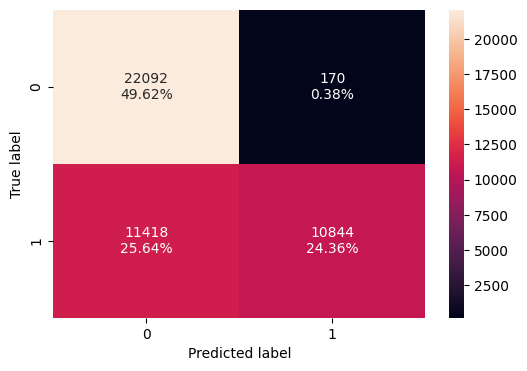

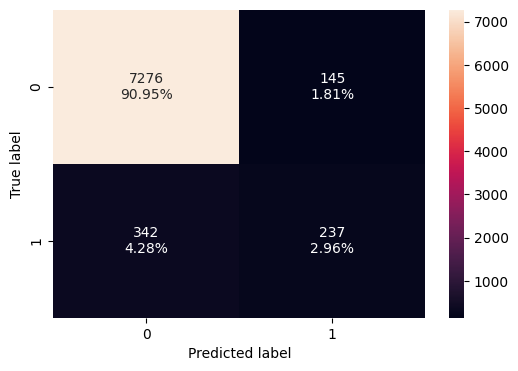

In [69]:
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(random_state=1)

# Grid of parameters to choose from for GradientBoostingClassifier
gbm_param_dist = {
    "n_estimators": np.arange(25,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.5,0.7,0.9],
    "max_features":[0.5,0.7,1],
    "max_depth": np.arange(1, 7, 1) # Added max_depth for GBM tuning
}

# use recall as the scoring criterion since we care about catching happy customers
scorer = make_scorer(recall_score)

search = RandomizedSearchCV(
    gbc_tuned,
    param_distributions=gbm_param_dist, # Use the GBM specific parameter distribution
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

best_gbm = search.best_estimator_
print("Best hyper‑parameters:", search.best_params_)

# evaluate performance
gbm_train_perf = model_performance_classification_sklearn(best_gbm, X_train_un, y_train_un)
gbm_test_perf = model_performance_classification_sklearn(best_gbm, X_val, y_val)

print("\nRandom‑forest performance on training set:") # Changed to reflect GBM
print(gbm_train_perf)

print("\nRandom‑forest performance on test set:") # Changed to reflect GBM
print(gbm_test_perf)

# confusion matrices
print("\nConfusion matrix – training set")
confusion_matrix_sklearn(best_gbm, X_train_over, y_train_over)
print("\nConfusion matrix – test set")
confusion_matrix_sklearn(best_gbm, X_val, y_val)

Best hyper‑parameters: {'subsample': 0.9, 'n_estimators': np.int64(100), 'max_features': 0.7, 'max_depth': np.int64(6), 'learning_rate': 0.05}

Random‑forest performance on training set:
   Accuracy  Recall  Precision    F1
0     0.777   0.560      0.990 0.715

Random‑forest performance on test set:
   Accuracy  Recall  Precision    F1
0     0.939   0.409      0.620 0.493

Confusion matrix – training set

Confusion matrix – test set


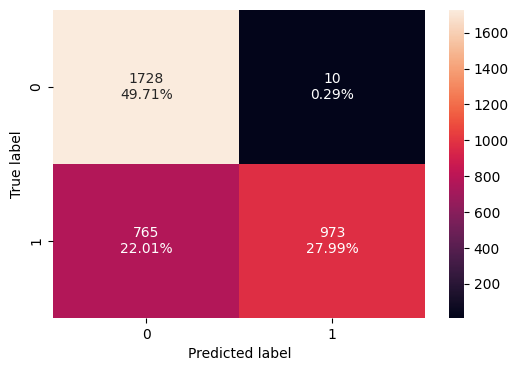

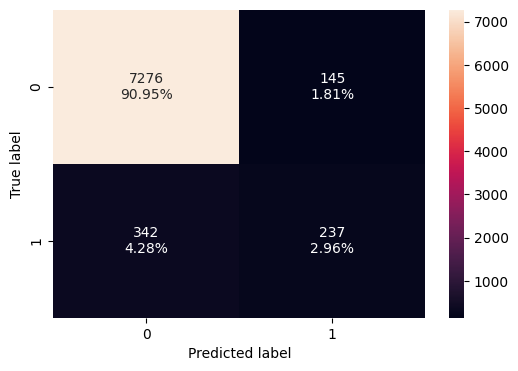

In [70]:
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(random_state=1)

# Grid of parameters to choose from for GradientBoostingClassifier
gbm_param_dist = {
    "n_estimators": np.arange(25,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.5,0.7,0.9],
    "max_features":[0.5,0.7,1],
    "max_depth": np.arange(1, 7, 1) # Added max_depth for GBM tuning
}

# use recall as the scoring criterion since we care about catching happy customers
scorer = make_scorer(recall_score)

search = RandomizedSearchCV(
    gbc_tuned,
    param_distributions=gbm_param_dist, # Use the GBM specific parameter distribution
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

best_gbm = search.best_estimator_
print("Best hyper‑parameters:", search.best_params_)

# evaluate performance
gbm_train_perf = model_performance_classification_sklearn(best_gbm, X_train_un, y_train_un)
gbm_test_perf = model_performance_classification_sklearn(best_gbm, X_val, y_val)

print("\nRandom‑forest performance on training set:") # Changed to reflect GBM
print(gbm_train_perf)

print("\nRandom‑forest performance on test set:") # Changed to reflect GBM
print(gbm_test_perf)

# confusion matrices
print("\nConfusion matrix – training set")
confusion_matrix_sklearn(best_gbm, X_train_un, y_train_un)
print("\nConfusion matrix – test set")
confusion_matrix_sklearn(best_gbm, X_val, y_val)

## Adaboost

Best hyper‑parameters: {'n_estimators': np.int64(100), 'learning_rate': 1, 'estimator__max_depth': 3}

AdaBoost performance on training set:
   Accuracy  Recall  Precision    F1
0     0.861   0.902      0.331 0.485

AdaBoost performance on validation set:
   Accuracy  Recall  Precision    F1
0     0.856   0.888      0.321 0.472

Confusion matrix – training set

Confusion matrix – validation set


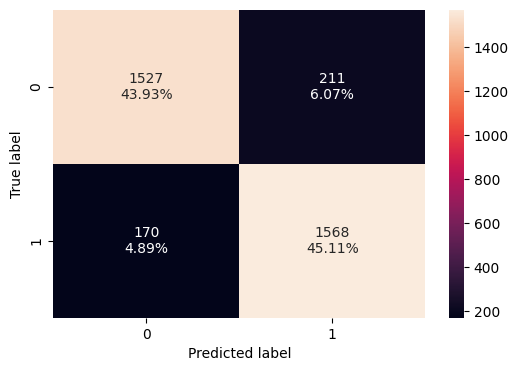

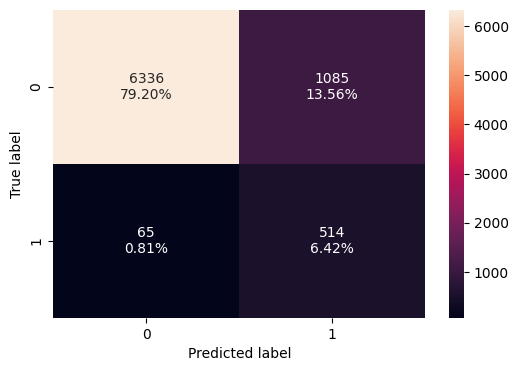

In [71]:
# Choose the type of classifier.
# Adaboost classifier with a Decision Tree Stump as base estimator
abc_tuned = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)

# Grid of parameters to choose from for AdaBoostClassifier
abc_param_dist = {
    "n_estimators": np.arange(50, 200, 50),
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1],
    "estimator__max_depth": [1, 2, 3] # Tuning max_depth of the base DecisionTreeClassifier
}

# use recall as the scoring criterion since we care about catching happy customers
scorer = make_scorer(recall_score)

search = RandomizedSearchCV(
    abc_tuned,
    param_distributions=abc_param_dist,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1,
)

# Fit on undersampled training data
search.fit(X_train_un, y_train_un)

best_abc = search.best_estimator_
print("Best hyper‑parameters:", search.best_params_)

# evaluate performance
abc_train_perf = model_performance_classification_sklearn(best_abc, X_train, y_train)
abc_test_perf = model_performance_classification_sklearn(best_abc, X_val, y_val)

print("\nAdaBoost performance on training set:")
print(abc_train_perf)

print("\nAdaBoost performance on validation set:")
print(abc_test_perf)

# confusion matrices
print("\nConfusion matrix – training set")
confusion_matrix_sklearn(best_abc, X_train_un, y_train_un)
print("\nConfusion matrix – validation set")
confusion_matrix_sklearn(best_abc, X_val, y_val)

Best hyper‑parameters: {'n_estimators': np.int64(100), 'learning_rate': 1, 'estimator__max_depth': 3}

AdaBoost performance on training set:
   Accuracy  Recall  Precision    F1
0     0.876   0.894      0.863 0.878

AdaBoost performance on validation set:
   Accuracy  Recall  Precision    F1
0     0.856   0.888      0.321 0.472

Confusion matrix – training set

Confusion matrix – validation set


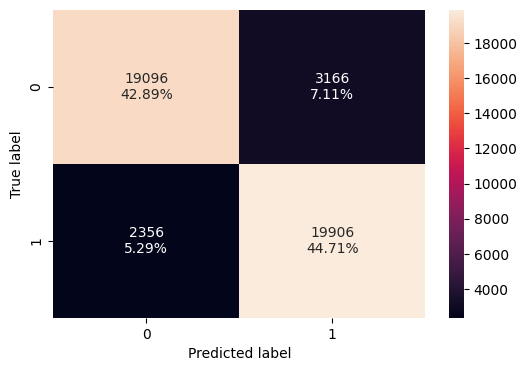

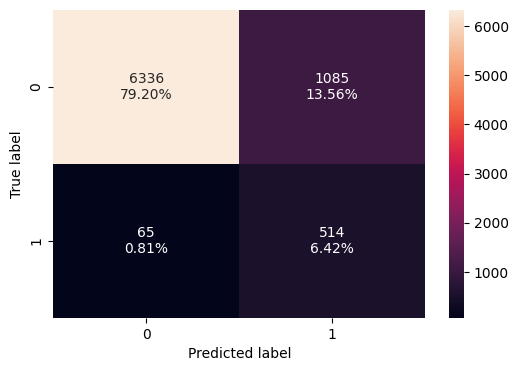

In [75]:
# Choose the type of classifier.
# Adaboost classifier with a Decision Tree Stump as base estimator
abc_tuned = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)

# Grid of parameters to choose from for AdaBoostClassifier
abc_param_dist = {
    "n_estimators": np.arange(50, 200, 50),
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1],
    "estimator__max_depth": [1, 2, 3] # Tuning max_depth of the base DecisionTreeClassifier
}

# use recall as the scoring criterion since we care about catching happy customers
scorer = make_scorer(recall_score)

search = RandomizedSearchCV(
    abc_tuned,
    param_distributions=abc_param_dist,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1,
)

# Fit on undersampled training data
search.fit(X_train_un, y_train_un)

best_abc = search.best_estimator_
print("Best hyper‑parameters:", search.best_params_)

# evaluate performance
abc_train_perf = model_performance_classification_sklearn(best_abc, X_train_over, y_train_over)
abc_test_perf = model_performance_classification_sklearn(best_abc, X_val, y_val)

print("\nAdaBoost performance on training set:")
print(abc_train_perf)

print("\nAdaBoost performance on validation set:")
print(abc_test_perf)

# confusion matrices
print("\nConfusion matrix – training set")
confusion_matrix_sklearn(best_abc, X_train_over, y_train_over)
print("\nConfusion matrix – validation set")
confusion_matrix_sklearn(best_abc, X_val, y_val)

Best hyper‑parameters: {'n_estimators': np.int64(100), 'learning_rate': 1, 'estimator__max_depth': 3}

AdaBoost performance on training set:
   Accuracy  Recall  Precision    F1
0     0.890   0.902      0.881 0.892

AdaBoost performance on validation set:
   Accuracy  Recall  Precision    F1
0     0.856   0.888      0.321 0.472

Confusion matrix – training set

Confusion matrix – validation set


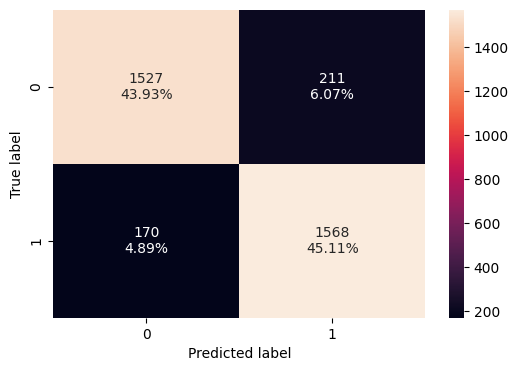

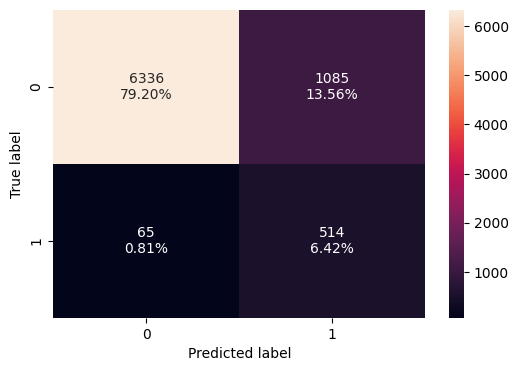

In [74]:
# Choose the type of classifier.
# Adaboost classifier with a Decision Tree Stump as base estimator
abc_tuned = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)

# Grid of parameters to choose from for AdaBoostClassifier
abc_param_dist = {
    "n_estimators": np.arange(50, 200, 50),
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1],
    "estimator__max_depth": [1, 2, 3] # Tuning max_depth of the base DecisionTreeClassifier
}

# use recall as the scoring criterion since we care about catching happy customers
scorer = make_scorer(recall_score)

search = RandomizedSearchCV(
    abc_tuned,
    param_distributions=abc_param_dist,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1,
)

# Fit on undersampled training data
search.fit(X_train_un, y_train_un)

best_abc = search.best_estimator_
print("Best hyper‑parameters:", search.best_params_)

# evaluate performance
abc_train_perf = model_performance_classification_sklearn(best_abc, X_train_un, y_train_un)
abc_test_perf = model_performance_classification_sklearn(best_abc, X_val, y_val)

print("\nAdaBoost performance on training set:")
print(abc_train_perf)

print("\nAdaBoost performance on validation set:")
print(abc_test_perf)

# confusion matrices
print("\nConfusion matrix – training set")
confusion_matrix_sklearn(best_abc, X_train_un, y_train_un)
print("\nConfusion matrix – validation set")
confusion_matrix_sklearn(best_abc, X_val, y_val)